
# Italian University Sustainability Analysis

This notebook explores the relationship between:
- **Sustainability performance**
- **Evidence/documentation intensity**
- **Efficiency indicators**
- **University rankings**

The analysis uses the dataset `italian_university_sustainability.csv` and includes:
- Data cleaning
- Feature engineering
- Correlation analysis
- Comparative university profiling
- Sustainability score visualisation
- Word clouds and term-frequency insights
- Efficiency vs sustainability comparisons
- Radar charts and clustering


In [19]:
pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from math import pi

plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("italian_university_sustainability.csv")

print(df.head())
print("\nShape:", df.shape)


           university               base_url evidence_level  pages_scanned  \
0              Tuscia  https://www.unitus.it      extensive             40   
1            Macerata   https://www.unimc.it      extensive             11   
2  Milano Politecnico  https://www.polimi.it      extensive             40   
3             Bologna   https://www.unibo.it      extensive             13   
4  Torino Politecnico  https://www.polito.it      extensive             39   

   pdf_count  latest_year  word_count  text_length  \
0        157       2026.0      812947      6330636   
1         57       2026.0      686448      4818452   
2         44       2026.0      838209      5898352   
3         29       2026.0     1212461      8477850   
4         28       2026.0      206988      1458070   

                                           top_terms  \
0  [["progetto", 3064], ["knowledge", 2603], ["ri...   
1  [["studenti", 6248], ["corso", 3113], ["valuta...   
2  [["politecnico", 5136], ["milano", 

In [21]:
df[['university','pages_scanned']]

,university,pages_scanned
0,Tuscia,40
1,Macerata,11
2,Milano Politecnico,40
3,Bologna,13
4,Torino Politecnico,39
5,Roma Tre,31
6,Piemonte Orientale,40
7,Padova,1
8,Urbino,40
9,Parma,13


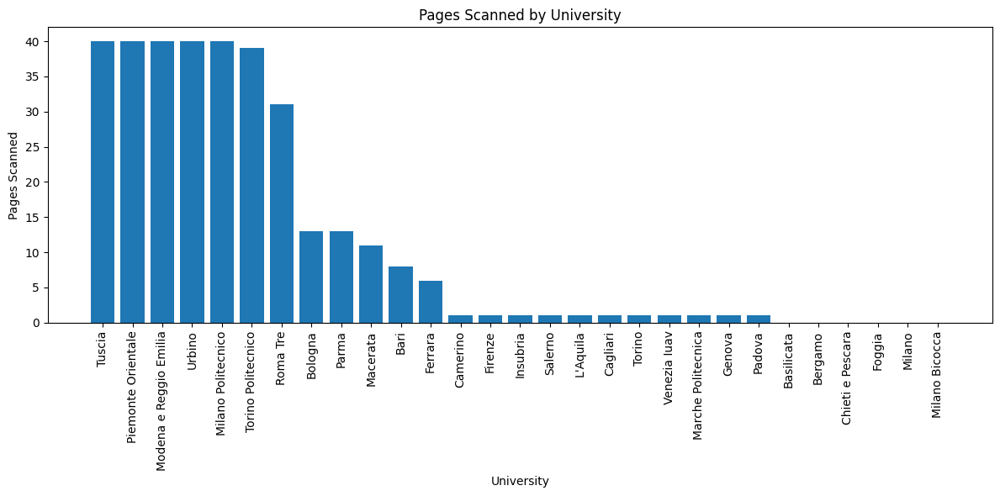

In [22]:
# Sort descending
plot_df = df.sort_values('pages_scanned', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(plot_df['university'], plot_df['pages_scanned'])

plt.xticks(rotation=90)
plt.xlabel('University')
plt.ylabel('Pages Scanned')
plt.title('Pages Scanned by University')

plt.tight_layout()
plt.show()


## Data Preparation

We create additional indicators to estimate:
- Sustainability intensity
- Evidence efficiency
- SDG coverage
- Documentation productivity


In [23]:

# Numeric SDG columns
sdg_cols = [
    "SDG3_Health","SDG4_Education","SDG5_Gender","SDG7_Energy",
    "SDG11_Cities","SDG12_Consumption","SDG13_Climate","SDG16_Governance"
]

# Feature engineering
df["total_sdg_score"] = df[sdg_cols].sum(axis=1)

df["docs_per_page"] = df["pdf_count"] / df["pages_scanned"]
df["words_per_pdf"] = df["word_count"] / df["pdf_count"]
df["text_per_page"] = df["text_length"] / df["pages_scanned"]
df["sustainability_density"] = df["total_sdg_score"] / df["word_count"] * 10000

# Rank universities
df["sustainability_rank"] = df["total_sdg_score"].rank(ascending=False)

df[[
    "university",
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]]


,university,total_sdg_score,sustainability_density,docs_per_page,words_per_pdf
0,Tuscia,3518,43.274654,3.925000,5.178006e+03
1,Macerata,274,3.991562,5.181818,1.204295e+04
2,Milano Politecnico,11665,139.165769,1.100000,1.905020e+04
3,Bologna,6616,54.566704,2.230769,4.180900e+04
4,Torino Politecnico,2851,137.737453,0.717949,7.392429e+03
5,Roma Tre,737,53.487191,0.580645,7.655000e+03
6,Piemonte Orientale,702,15.332733,0.350000,3.270314e+04
7,Padova,955,50.793279,14.000000,1.342979e+04
8,Urbino,209,26.126960,0.275000,7.272182e+03
9,Parma,163,22.853137,0.307692,1.783125e+04



## Sustainability Ranking


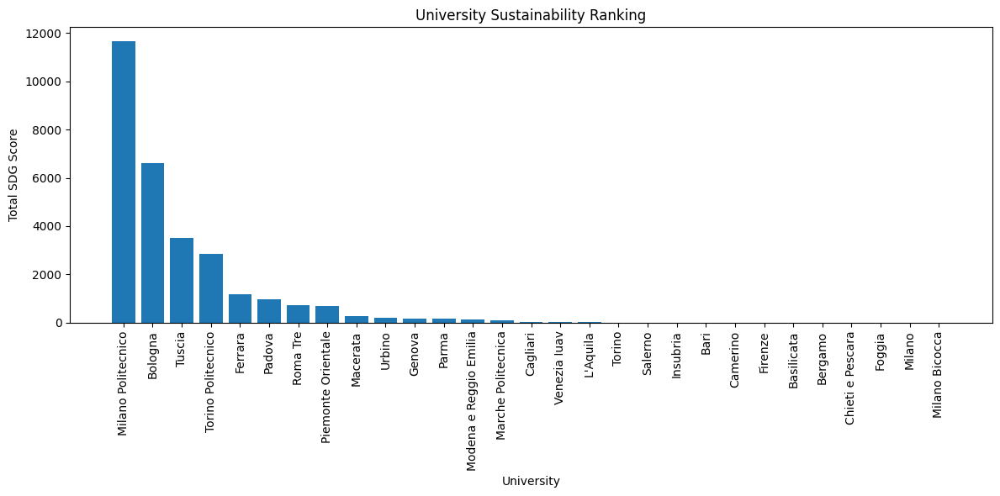

,university,total_sdg_score
2,Milano Politecnico,11665
3,Bologna,6616
0,Tuscia,3518
4,Torino Politecnico,2851
12,Ferrara,1164
7,Padova,955
5,Roma Tre,737
6,Piemonte Orientale,702
1,Macerata,274
8,Urbino,209


In [24]:
ranking = df.sort_values("total_sdg_score", ascending=False)[
    ["university", "total_sdg_score"]
]

plt.figure(figsize=(12,6))

plt.bar(
    ranking["university"],
    ranking["total_sdg_score"]
)

# Make labels vertical
plt.xticks(rotation=90)

plt.ylabel("Total SDG Score")
plt.xlabel("University")
plt.title("University Sustainability Ranking")

plt.tight_layout()
plt.show()

ranking


## Correlation Analysis

This section examines relationships between:
- Sustainability score
- Number of PDFs
- Word count
- Text length
- Documentation efficiency


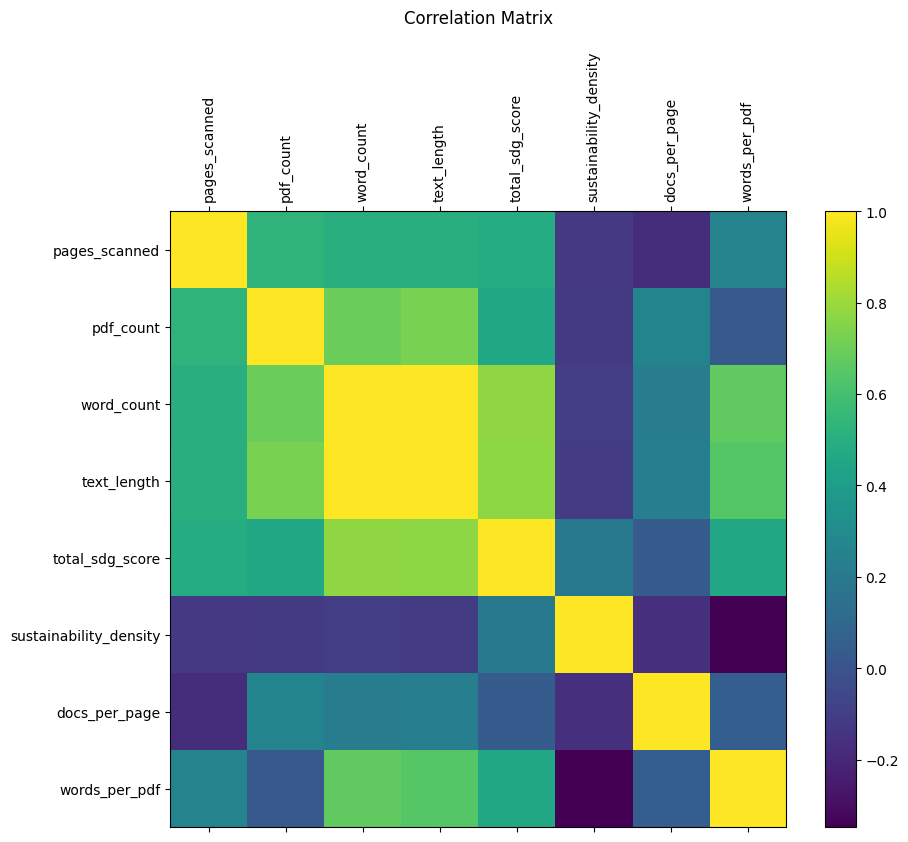

,pages_scanned,pdf_count,word_count,text_length,total_sdg_score,sustainability_density,docs_per_page,words_per_pdf
pages_scanned,1.000000,0.531310,0.495236,0.502949,0.486530,-0.125138,-0.168462,0.256937
pdf_count,0.531310,1.000000,0.695573,0.728012,0.459412,-0.116128,0.258130,0.030822
word_count,0.495236,0.695573,1.000000,0.998795,0.777537,-0.104881,0.223976,0.673205
text_length,0.502949,0.728012,0.998795,1.000000,0.772920,-0.105897,0.229163,0.646210
total_sdg_score,0.486530,0.459412,0.777537,0.772920,1.000000,0.199940,0.043469,0.457869
sustainability_density,-0.125138,-0.116128,-0.104881,-0.105897,0.199940,1.000000,-0.160280,-0.347383
docs_per_page,-0.168462,0.258130,0.223976,0.229163,0.043469,-0.160280,1.000000,0.057847
words_per_pdf,0.256937,0.030822,0.673205,0.646210,0.457869,-0.347383,0.057847,1.000000


In [25]:

corr_cols = [
    "pages_scanned",
    "pdf_count",
    "word_count",
    "text_length",
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.matshow(corr, cmap="viridis")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

fig.colorbar(cax)
plt.title("Correlation Matrix", pad=20)
plt.show()

corr



## Efficiency vs Sustainability

A key question:
> Do universities producing more documentation also demonstrate stronger sustainability performance?


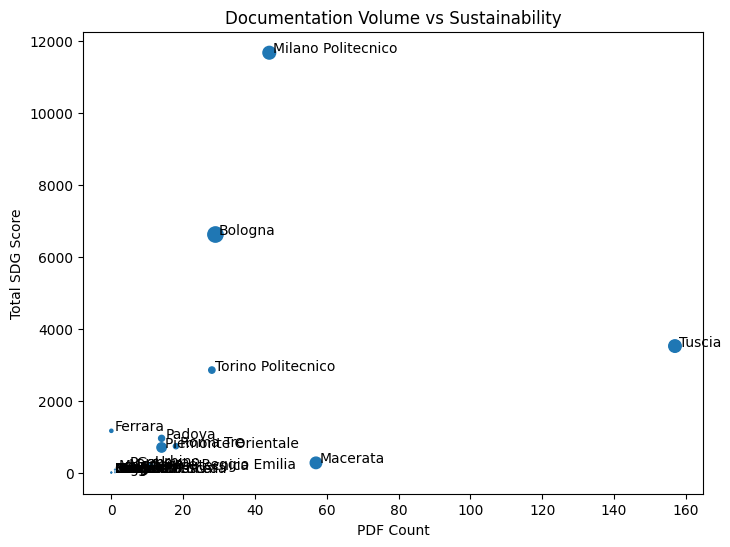

In [26]:

plt.figure(figsize=(8,6))

plt.scatter(
    df["pdf_count"],
    df["total_sdg_score"],
    s=df["word_count"]/10000,
)

for _, row in df.iterrows():
    plt.text(row["pdf_count"]+1, row["total_sdg_score"], row["university"])

plt.xlabel("PDF Count")
plt.ylabel("Total SDG Score")
plt.title("Documentation Volume vs Sustainability")

plt.show()



## Sustainability Density

This metric estimates how efficiently sustainability content is embedded relative to total text size.


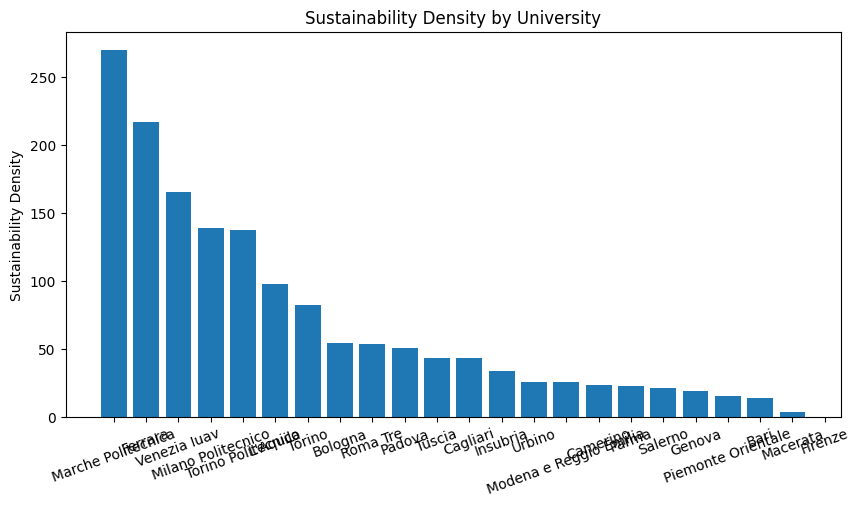

,university,sustainability_density
15,Marche Politecnica,269.930948
12,Ferrara,217.464410
16,Venezia Iuav,165.593376
2,Milano Politecnico,139.165769
4,Torino Politecnico,137.737453
19,L'Aquila,98.107919
17,Torino,82.644628
3,Bologna,54.566704
5,Roma Tre,53.487191
7,Padova,50.793279


In [27]:

density = df.sort_values("sustainability_density", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(density["university"], density["sustainability_density"])
plt.xticks(rotation=20)
plt.ylabel("Sustainability Density")
plt.title("Sustainability Density by University")
plt.show()

density[[
    "university",
    "sustainability_density"
]]



## Word Frequency Analysis

The dataset includes extracted `top_terms` for each university.  
We generate word clouds to visualise dominant themes.


In [28]:
efficiency_keywords = {

    # =========================
    # STAFF STRUCTURE
    # =========================
    "teachingstaff","internalteachingstaff","academicstaff",
    "nonacademicstaff","universitystaff","faculty",
    "professors","fullprofessors","associateprofessor",
    "researchers","tenuredresearchers","fixedtermresearchers",
    "researchfellows","adjunctfaculty","administrativestaff",
    "technicalstaff","executivestaff",

    # =========================
    # AGE / HUMAN CAPITAL STRUCTURE
    # =========================
    "averageage","ageprofessors","agestaff",
    "agefaculty","ageinternalstaff",

    # =========================
    # STUDENTS / ENROLMENT
    # =========================
    "students","enrolledstudents","firstyear","firstyearstudents",
    "entrance","firsttimeentrance","regularstudents",
    "graduates","graduation","graduationrate",
    "phd","phdstudents","doctoral","specialisation",
    "masters","mastersprogrammes",

    # =========================
    # PERFORMANCE OUTCOMES
    # =========================
    "employed","employment","employability",
    "satisfaction","graduatesatisfaction",
    "retention","dropout","inactive",
    "creditsabroad","internship","placements",
    "career","jobplacement",

    # =========================
    # TEACHING EFFICIENCY
    # =========================
    "studentstaffratio","ratio",
    "teachingquality","credits",
    "curriculum","learningoutcomes",

    # =========================
    # FINANCIAL PERFORMANCE
    # =========================
    "revenue","revenues","income","funding",
    "publicrevenue","privatefunding","europerevenue",
    "expenditures","costs","operatingcosts",
    "personnelcosts","budget","netbalance",
    "netresult","economicresult","equity",
    "debt","indebtedness","sustainabilityindex",

    # =========================
    # RESEARCH OUTPUT
    # =========================
    "publications","researchoutput","articles",
    "citations","highlycited","nature","science",
    "phdawarded","doctoraloutput",

    # =========================
    # FUNDING STRUCTURE
    # =========================
    "ffo","fundingquota","performancefunding",
    "eufunding","grants","externalfunding"
}

In [29]:
def is_relevant(term):
    return (
        any(k in term for k in esg_keywords) or
        any(k in term for k in efficiency_keywords)
    )

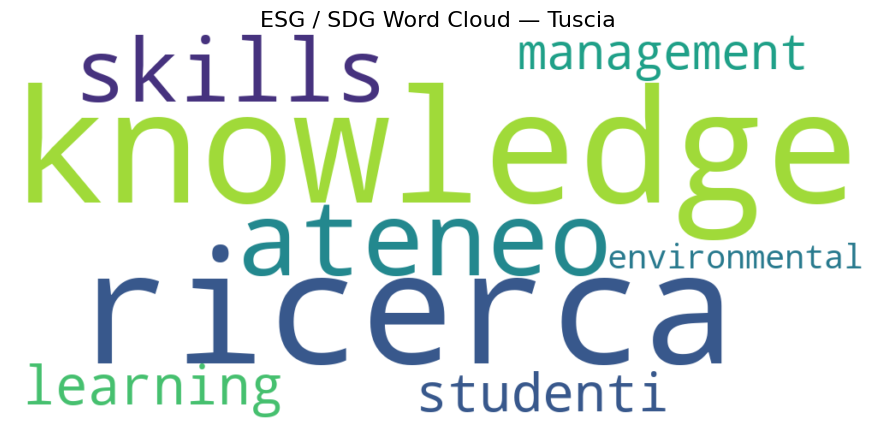

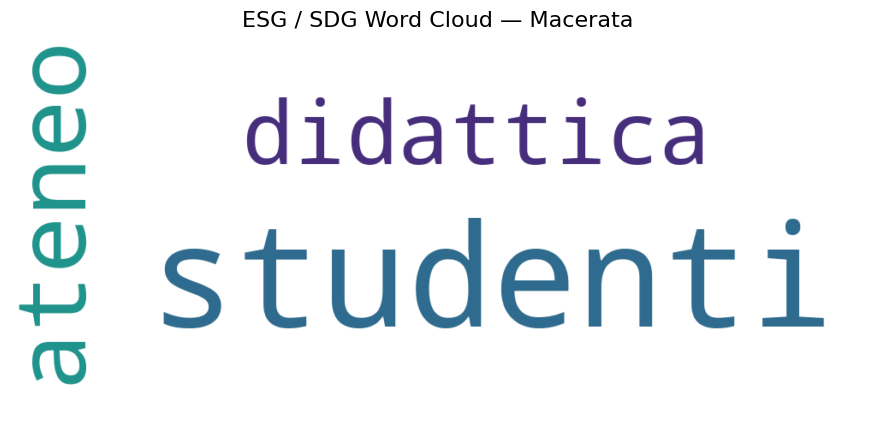

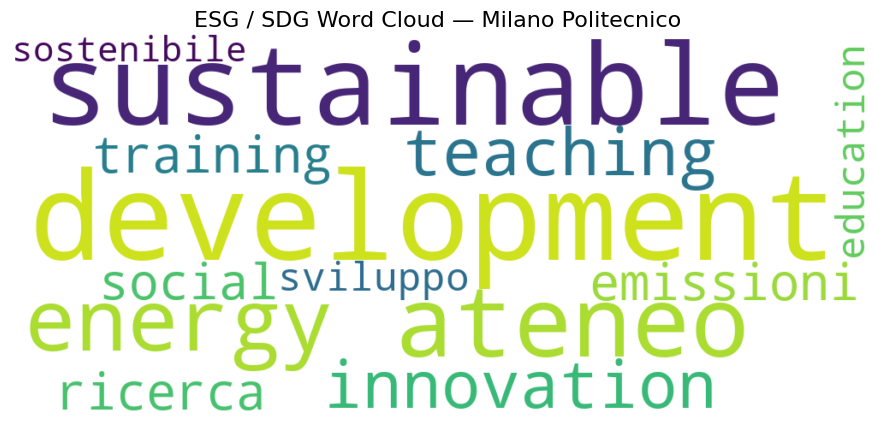

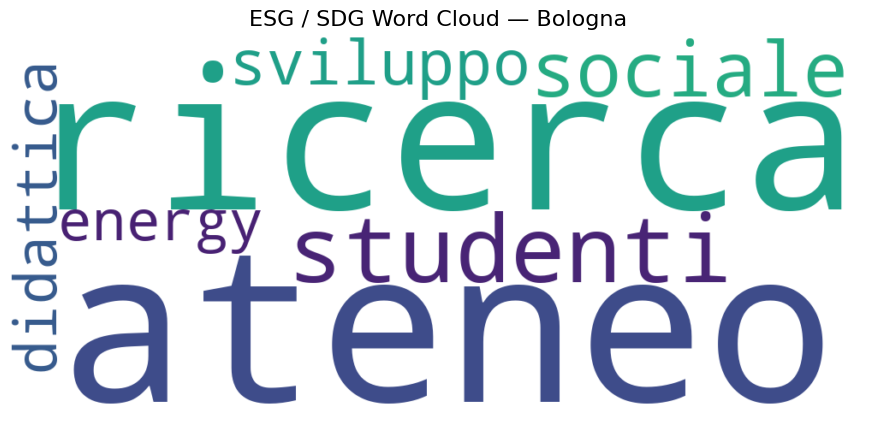

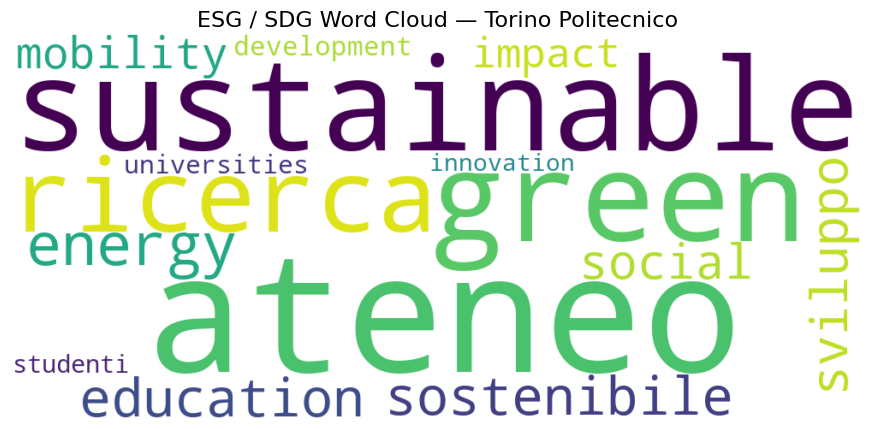

...

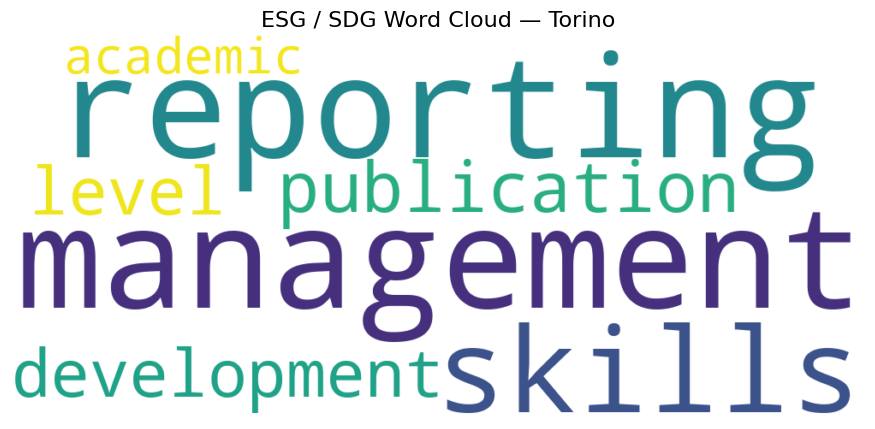

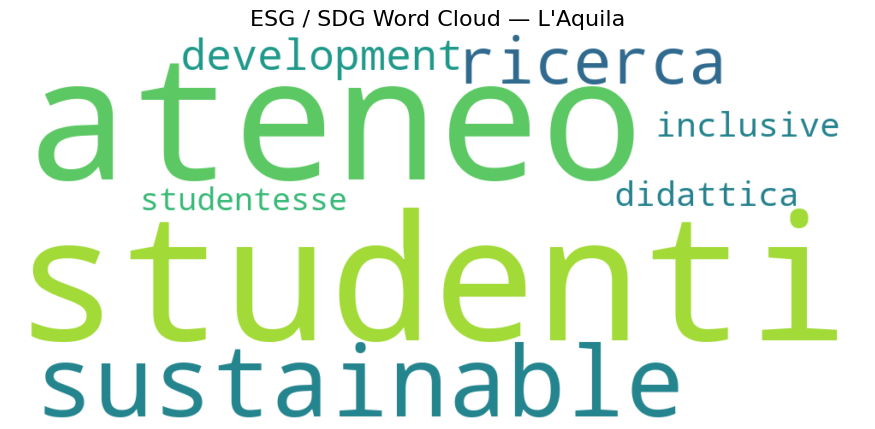

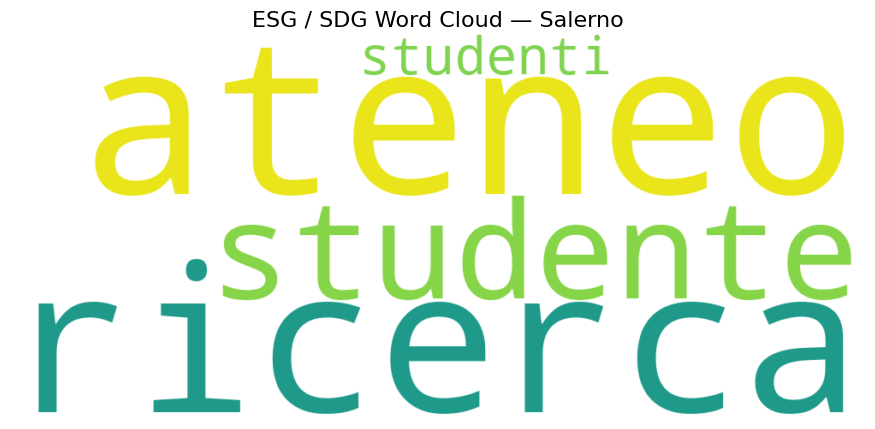

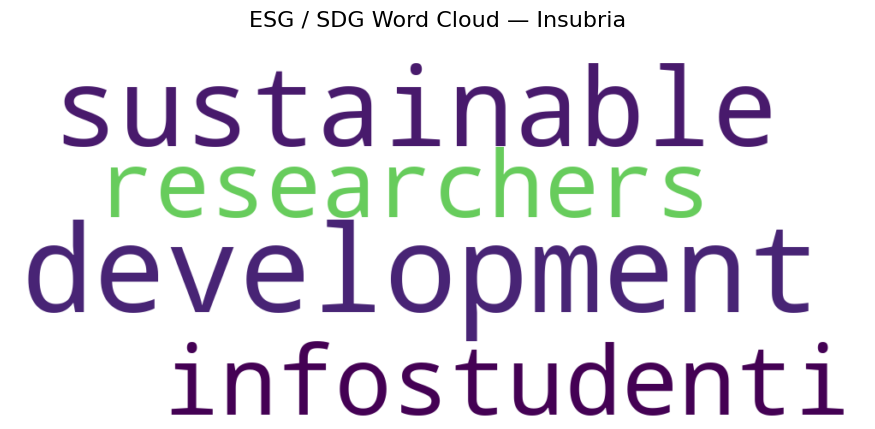

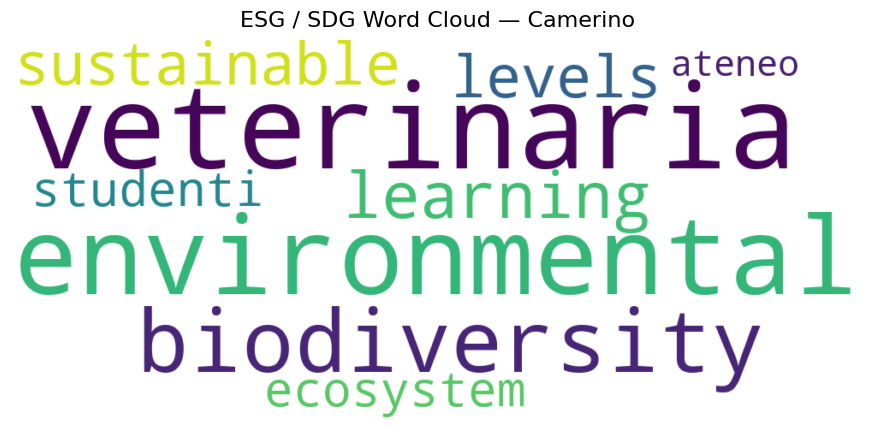

In [30]:
esg_keywords = {

    # =========================
    # GENERAL ESG / SDG
    # =========================
    "esg","sdg","sdgs","agenda2030","sustainability","sustainable",
    "sostenibilita","sostenibile","sviluppo","development",
    "responsibility","responsabile","impact","impatto",
    "resilience","resilienza","transition","transizione",
    "netzero","carbonneutral","climatepositive",

    # =========================
    # ENVIRONMENT
    # =========================
    "environment","environmental","ambiente","ambientale",
    "ecology","ecological","ecologia","ecosystem","ecosystems",
    "ecosistemi","natural","nature","natura",
    "planet","earth","territory","territorio",
    "land","soil","suolo","water","acqua","air","aria",
    "pollution","pollutione","contamination","contaminazione",
    "marine","oceans","sea","coastal","river","rivers",
    "forest","forests","forestry","forestale","forestali",
    "wildlife","habitat","species","flora","fauna",
    "green","greening","rewilding","conservation","conservazione",
    "restoration","restauro","regeneration","rigenerazione",

    # =========================
    # CLIMATE
    # =========================
    "climate","climatic","climatico","climatica",
    "globalwarming","warming","temperature",
    "adaptation","adaptatione","mitigation","mitigazione",
    "decarbonization","decarbonisation","decarbonizzazione",
    "emissions","emissioni","co2","ghg","methane",
    "carbon","footprint","offset","offsetting",
    "resilience","extremeweather","heatwave","drought",
    "flood","flooding","wildfire","risk","hazard",

    # =========================
    # ENERGY
    # =========================
    "energy","energia","renewable","renewables",
    "solar","photovoltaic","wind","hydrogen",
    "biofuel","biomass","geothermal","storage",
    "battery","smartgrid","efficiency","efficient",
    "electrification","electricity","power",
    "cleanenergy","lowcarbon","energyefficiency",
    "decentralized","microgrid",

    # =========================
    # CIRCULAR ECONOMY
    # =========================
    "circular","circolare","circulareconomy",
    "reuse","recycle","recycling","recycled",
    "recovery","recover","remanufacturing",
    "repair","upcycle","upcycling",
    "waste","wastes","wastewater",
    "compost","composting","resource",
    "resourceefficiency","materials",
    "materialefficiency","zerowaste",

    # =========================
    # BIODIVERSITY
    # =========================
    "biodiversity","biodiversita",
    "species","ecosystem","habitat",
    "pollinator","pollinators","wetlands",
    "protectedareas","ecoregion",
    "agroecology","ecologicalcorridor",
    "naturalcapital","naturebased",
    "conservation","ecorestoration",

    # =========================
    # AGRICULTURE / FOOD
    # =========================
    "agriculture","agricultural","agro",
    "food","foodsystems","nutrition",
    "farming","organic","organicfarming",
    "sustainablefarming","soilhealth",
    "precisionagriculture","livestock",
    "crop","crops","irrigation",
    "agritech","agroforestry",

    # =========================
    # WATER
    # =========================
    "water","freshwater","drinkingwater",
    "sanitation","wastewater","hydrology",
    "watershed","aquifer","desalination",
    "watersecurity","waterquality",
    "hydric","blueeconomy",

    # =========================
    # MOBILITY / CITIES
    # =========================
    "mobility","transport","transportation",
    "urban","city","cities","smartcity",
    "sustainablemobility","cycling",
    "walkability","publictransport",
    "rail","metro","traffic",
    "infrastructure","infrastructures",
    "urbanism","urbanplanning",
    "housing","buildings","construction",
    "bioarchitecture","bioedilizia",

    # =========================
    # SOCIAL
    # =========================
    "social","community","communities",
    "citizens","citizen","public",
    "participation","engagement",
    "wellbeing","wellness","health",
    "mentalhealth","inclusion","inclusive",
    "diversity","equity","equality",
    "justice","humanrights",
    "accessibility","solidarity",
    "cohesion","welfare","poverty",
    "employment","labour","workers",
    "safety","security",

    # =========================
    # GENDER
    # =========================
    "gender","women","female",
    "empowerment","feminism",
    "parity","equalopportunity",
    "inclusivity","discrimination",
    "harassment","bias",

    # =========================
    # EDUCATION
    # =========================
    "education","learning","teaching",
    "training","knowledge","research",
    "innovation","skills","capacity",
    "capacitybuilding","awareness",
    "curriculum","didactics",
    "student","students","academic",
    "pedagogy","school","schools",
    "university","universities",

    # =========================
    # GOVERNANCE
    # =========================
    "governance","ethics","ethical",
    "transparency","accountability",
    "compliance","integrity",
    "anticorruption","corruption",
    "leadership","stakeholder",
    "stakeholders","policy","policies",
    "regulation","standards",
    "reporting","disclosure",
    "audit","riskmanagement",
    "institutional","management",

    # =========================
    # ECONOMY / FINANCE
    # =========================
    "finance","financial","investment",
    "greenfinance","sustainablefinance",
    "economy","economic","growth",
    "inclusivegrowth","circularbusiness",
    "innovation","entrepreneurship",
    "impactinvesting","esginvesting",
    "taxonomy","csrd","euetaxonomy",

    # =========================
    # TECHNOLOGY
    # =========================
    "technology","digital","digitalization",
    "digitalisation","ai","artificialintelligence",
    "machinelearning","iot","bigdata",
    "datadriven","innovation","cleantech",
    "greentech","smart","automation",

    # =========================
    # SDG-SPECIFIC TERMS
    # =========================
    "zerohunger","goodhealth","qualityeducation",
    "cleanwater","cleanenergy",
    "decentwork","industry","innovation",
    "reducedinequalities","responsibleconsumption",
    "climateaction","lifebelowwater",
    "lifeonland","peace","partnerships",

    # =========================
    # ITALIAN UNIVERSITY / POLICY TERMS
    # =========================
    "ricerca","didattica","ateneo",
    "studenti","territoriale",
    "innovazione","energia","emissioni",
    "mobilita","clima","governance",
    "equita","inclusione","benessere",
    "transizione","economiacircolare",
    "rigenerazione","biodiversita",
    "decarbonizzazione","resilienza",
    "partecipazione","comunita",
    "responsabilita","svilupposostenibile",

    # =========================
    # REPORTING / DISCLOSURE
    # =========================
    "gri","sasb","tcfd","issb",
    "csr","csrd","esrs","unep",
    "ungc","scope1","scope2","scope3",
    "materiality","doublemateriality",
    "nonfinancial","sustainabilityreport",
    "integratedreport","impactreport",

    # =========================
    # HEALTH / WELLBEING
    # =========================
    "healthcare","publichealth","medicine",
    "epidemiology","wellbeing","wellness",
    "nutrition","prevention","hospital",
    "care","disability","access",

    # =========================
    # ETHICS / HUMAN RIGHTS
    # =========================
    "humanrights","rights","equity",
    "ethics","ethical","fairness",
    "freedom","dignity","inclusion",
    "justice","transparency","participation",

    # =========================
    # CLIMATE SCIENCE
    # =========================
    "adaptation","mitigation","carbonbudget",
    "decarbonize","climatescience",
    "resilience","vulnerability",
    "sustainablesystems","energytransition",

    # =========================
    # BUILT ENVIRONMENT
    # =========================
    "greenbuilding","leed","breeam",
    "smartbuilding","retrofit",
    "sustainablearchitecture",
    "landscape","urbanecology",
    "naturebasedsolutions",

    # =========================
    # TRANSPORT
    # =========================
    "electricvehicle","ev","charging",
    "micromobility","bike","cycling",
    "publicmobility","sharedmobility",

    # =========================
    # PROCUREMENT / SUPPLY CHAIN
    # =========================
    "supplychain","procurement",
    "sustainableprocurement",
    "traceability","supplier",
    "localproduction","ethicalsourcing",

    # =========================
    # WASTE / MATERIALS
    # =========================
    "plastic","plastics","packaging",
    "singleuse","remanufacture",
    "reuse","landfill","incineration",

    # =========================
    # RESILIENCE / RISK
    # =========================
    "adaptiverisk","resilienceplanning",
    "climaterisk","supplyrisk",
    "preparedness","disasterrisk"
}

def parse_terms(term_string):
    try:
        parsed = ast.literal_eval(term_string)
        return {term.lower(): freq for term, freq in parsed}
    except:
        return {}

for idx, row in df.iterrows():

    terms = parse_terms(row["top_terms"])

    # Filter only ESG/SDG-related terms
    filtered_terms = {
        term: freq
        for term, freq in terms.items()
        if is_relevant(term)
    }

    if len(filtered_terms) == 0:
        continue

    wc = WordCloud(
        width=1000,
        height=450,
        background_color="white"
    ).generate_from_frequencies(filtered_terms)

    plt.figure(figsize=(13,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    plt.title(
        f"ESG / SDG Word Cloud — {row['university']}",
        fontsize=16
    )

    plt.show()

In [31]:
# ==========================================
# SAVE ALL ESG / SDG WORD CLOUDS TO FILES
# Folder: ~/Downloads/uni_clouds
# ==========================================

import os
import ast
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create output folder in Downloads
output_dir = os.path.join(os.path.expanduser("~"), "Downloads", "uni_clouds")
os.makedirs(output_dir, exist_ok=True)

for idx, row in df.iterrows():

    terms = parse_terms(row["top_terms"])

    # Filter ESG/SDG terms
    filtered_terms = {
        term: freq
        for term, freq in terms.items()
        if is_relevant(term)
    }

    # Skip empty clouds
    if len(filtered_terms) == 0:
        continue

    # Generate word cloud
    wc = WordCloud(
        width=1000,
        height=450,
        background_color="white"
    ).generate_from_frequencies(filtered_terms)

    # Create figure
    plt.figure(figsize=(13,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    plt.title(
        f"ESG / SDG Word Cloud — {row['university']}",
        fontsize=16
    )

    # Clean filename
    uni_name = str(row["university"]).replace("/", "_").replace("\\", "_")
    uni_name = uni_name.replace(" ", "_")

    save_path = os.path.join(output_dir, f"{uni_name}_wordcloud.png")

    # Save image
    plt.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

print(f"All word clouds saved to:\n{output_dir}")

All word clouds saved to:
/Users/eddiek/Downloads/uni_clouds


In [32]:
# Create output folder once before the loop
import os

output_dir = os.path.join(os.path.expanduser("~"), "Downloads", "uni_clouds")
os.makedirs(output_dir, exist_ok=True)

# Inside your loop, BEFORE plt.show()

uni_name = str(row["university"]).replace("/", "_").replace("\\", "_")
uni_name = uni_name.replace(" ", "_")

save_path = os.path.join(output_dir, f"{uni_name}_wordcloud.png")

plt.savefig(save_path, bbox_inches="tight", dpi=300)

<Figure size 1000x600 with 0 Axes>

In [33]:
# Save all ESG / SDG word clouds to a folder called "Uni Word Clouds"
# in your Downloads directory

from pathlib import Path
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast

# Create output folder
output_dir = Path.home() / "Downloads" / "Uni Word Clouds"
output_dir.mkdir(parents=True, exist_ok=True)

def parse_terms(term_string):
    try:
        parsed = ast.literal_eval(term_string)
        return {term.lower(): freq for term, freq in parsed}
    except:
        return {}

for idx, row in df.iterrows():

    terms = parse_terms(row["top_terms"])

    # Filter ESG/SDG-related terms
    filtered_terms = {
        term: freq
        for term, freq in terms.items()
        if is_relevant(term)
    }

    if len(filtered_terms) == 0:
        continue

    wc = WordCloud(
        width=1000,
        height=450,
        background_color="white"
    ).generate_from_frequencies(filtered_terms)

    # Create figure
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")

    title = f"ESG / SDG Word Cloud — {row['university']}"
    ax.set_title(title, fontsize=16)

    # Clean filename
    safe_name = (
        str(row["university"])
        .replace("/", "-")
        .replace("\\", "-")
        .replace(":", "-")
        .strip()
    )

    save_path = output_dir / f"{safe_name}.png"

    # Save image
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

print(f"Saved word clouds to:\n{output_dir}")

Saved word clouds to:
/Users/eddiek/Downloads/Uni Word Clouds


In [34]:
high_eff_low_sust = ['Bari', 'Bologna', 'Firenze', 'Milano',
                     'Milano Politecnico', 'Padova', 'Parma', 'Torino']

low_eff_high_sust = ['Basilicata', 'Bergamo', 'Chieti e Pescara',
                     'Ferrara', 'Macerata', 'Piemonte Orientale',
                     'Urbino', 'Venezia Iuav']

high_eff_high_sust = ['Cagliari', 'Genova', 'Milano Bicocca',
                      'Modena e Reggio Emilia', 'Roma Tre',
                      'Salerno', 'Torino Politecnico']

low_eff_low_sust = ['Camerino', 'Foggia', 'Insubria',
                    "L'Aquila", 'Marche Politecnica', 'Tuscia']

quadrants = {
    "High Eff / Low Sust": high_eff_low_sust,
    "Low Eff / High Sust": low_eff_high_sust,
    "High Eff / High Sust": high_eff_high_sust,
    "Low Eff / Low Sust": low_eff_low_sust
}

In [35]:
def assign_quadrant(university):
    if university in high_eff_low_sust:
        return "High Eff / Low Sust"
    elif university in low_eff_high_sust:
        return "Low Eff / High Sust"
    elif university in high_eff_high_sust:
        return "High Eff / High Sust"
    elif university in low_eff_low_sust:
        return "Low Eff / Low Sust"
    else:
        return "Unassigned"

df["quadrant"] = df["university"].apply(assign_quadrant)

In [36]:
for name, subset in df.groupby("quadrant"):
    if name == "Unassigned":
        continue

    build_quadrant_wordcloud(df, subset["university"].tolist(), f"Word Wall — {name}")

NameError: name 'build_quadrant_wordcloud' is not defined


# Italian University Sustainability Analysis

This notebook explores the relationship between:
- **Sustainability performance**
- **Evidence/documentation intensity**
- **Efficiency indicators**
- **University rankings**

The analysis uses the dataset `italian_university_sustainability.csv` and includes:
- Data cleaning
- Feature engineering
- Correlation analysis
- Comparative university profiling
- Sustainability score visualisation
- Word clouds and term-frequency insights
- Efficiency vs sustainability comparisons
- Radar charts and clustering


In [ ]:
pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from math import pi

plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("italian_university_sustainability.csv")

print(df.head())
print("\nShape:", df.shape)


           university               base_url evidence_level  pages_scanned  \
0              Tuscia  https://www.unitus.it      extensive             40   
1            Macerata   https://www.unimc.it      extensive             11   
2  Milano Politecnico  https://www.polimi.it      extensive             40   
3             Bologna   https://www.unibo.it      extensive             13   
4  Torino Politecnico  https://www.polito.it      extensive             39   

   pdf_count  latest_year  word_count  text_length  \
0        157       2026.0      812947      6330636   
1         57       2026.0      686448      4818452   
2         44       2026.0      838209      5898352   
3         29       2026.0     1212461      8477850   
4         28       2026.0      206988      1458070   

                                           top_terms  \
0  [["progetto", 3064], ["knowledge", 2603], ["ri...   
1  [["studenti", 6248], ["corso", 3113], ["valuta...   
2  [["politecnico", 5136], ["milano", 


## Data Preparation

We create additional indicators to estimate:
- Sustainability intensity
- Evidence efficiency
- SDG coverage
- Documentation productivity


In [ ]:

# Numeric SDG columns
sdg_cols = [
    "SDG3_Health","SDG4_Education","SDG5_Gender","SDG7_Energy",
    "SDG11_Cities","SDG12_Consumption","SDG13_Climate","SDG16_Governance"
]

# Feature engineering
df["total_sdg_score"] = df[sdg_cols].sum(axis=1)

df["docs_per_page"] = df["pdf_count"] / df["pages_scanned"]
df["words_per_pdf"] = df["word_count"] / df["pdf_count"]
df["text_per_page"] = df["text_length"] / df["pages_scanned"]
df["sustainability_density"] = df["total_sdg_score"] / df["word_count"] * 10000

# Rank universities
df["sustainability_rank"] = df["total_sdg_score"].rank(ascending=False)

df[[
    "university",
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]]


,university,total_sdg_score,sustainability_density,docs_per_page,words_per_pdf
0,Tuscia,3518,43.274654,3.925000,5.178006e+03
1,Macerata,274,3.991562,5.181818,1.204295e+04
2,Milano Politecnico,11665,139.165769,1.100000,1.905020e+04
3,Bologna,6616,54.566704,2.230769,4.180900e+04
4,Torino Politecnico,2851,137.737453,0.717949,7.392429e+03
5,Roma Tre,737,53.487191,0.580645,7.655000e+03
6,Piemonte Orientale,702,15.332733,0.350000,3.270314e+04
7,Padova,955,50.793279,14.000000,1.342979e+04
8,Urbino,209,26.126960,0.275000,7.272182e+03
9,Parma,163,22.853137,0.307692,1.783125e+04



## Sustainability Ranking


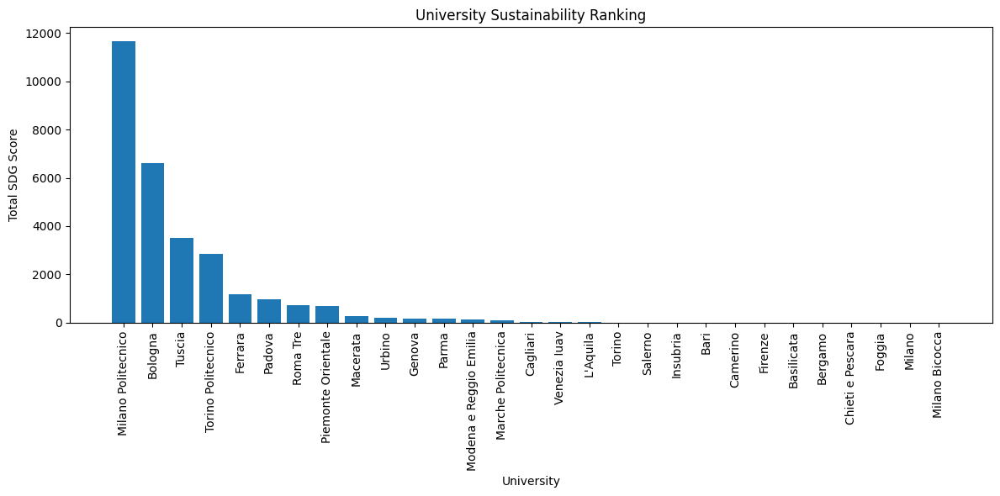

,university,total_sdg_score
2,Milano Politecnico,11665
3,Bologna,6616
0,Tuscia,3518
4,Torino Politecnico,2851
12,Ferrara,1164
7,Padova,955
5,Roma Tre,737
6,Piemonte Orientale,702
1,Macerata,274
8,Urbino,209


In [ ]:
ranking = df.sort_values("total_sdg_score", ascending=False)[
    ["university", "total_sdg_score"]
]

plt.figure(figsize=(12,6))

plt.bar(
    ranking["university"],
    ranking["total_sdg_score"]
)

# Make labels vertical
plt.xticks(rotation=90)

plt.ylabel("Total SDG Score")
plt.xlabel("University")
plt.title("University Sustainability Ranking")

plt.tight_layout()
plt.show()

ranking


## Correlation Analysis

This section examines relationships between:
- Sustainability score
- Number of PDFs
- Word count
- Text length
- Documentation efficiency


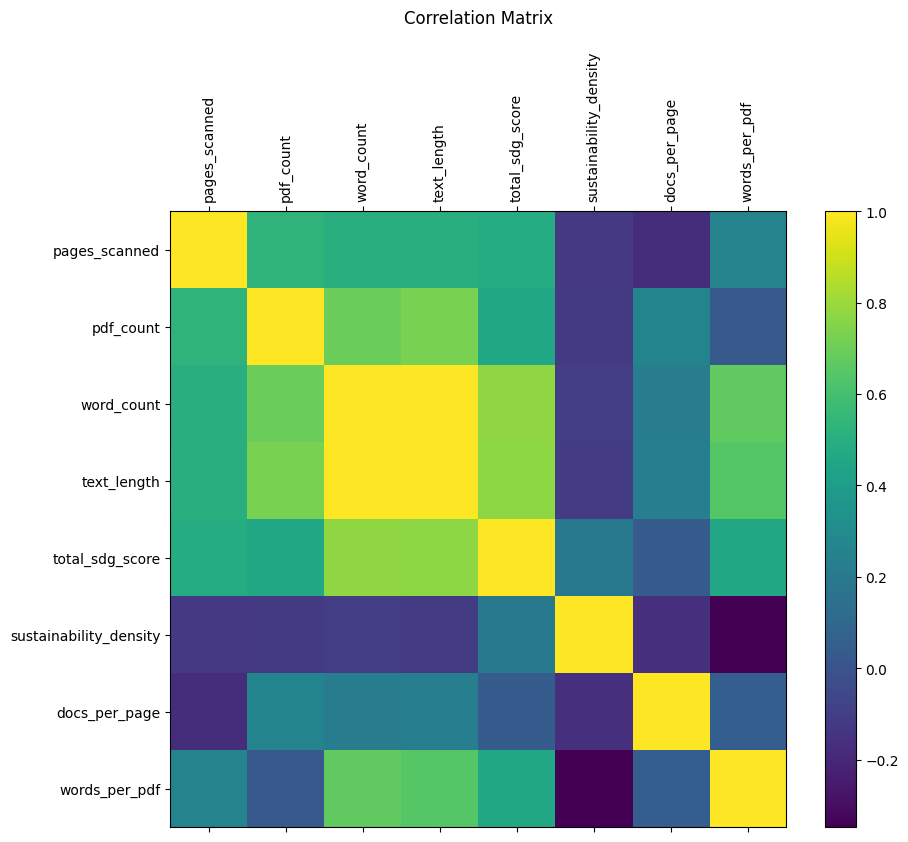

,pages_scanned,pdf_count,word_count,text_length,total_sdg_score,sustainability_density,docs_per_page,words_per_pdf
pages_scanned,1.000000,0.531310,0.495236,0.502949,0.486530,-0.125138,-0.168462,0.256937
pdf_count,0.531310,1.000000,0.695573,0.728012,0.459412,-0.116128,0.258130,0.030822
word_count,0.495236,0.695573,1.000000,0.998795,0.777537,-0.104881,0.223976,0.673205
text_length,0.502949,0.728012,0.998795,1.000000,0.772920,-0.105897,0.229163,0.646210
total_sdg_score,0.486530,0.459412,0.777537,0.772920,1.000000,0.199940,0.043469,0.457869
sustainability_density,-0.125138,-0.116128,-0.104881,-0.105897,0.199940,1.000000,-0.160280,-0.347383
docs_per_page,-0.168462,0.258130,0.223976,0.229163,0.043469,-0.160280,1.000000,0.057847
words_per_pdf,0.256937,0.030822,0.673205,0.646210,0.457869,-0.347383,0.057847,1.000000


In [ ]:

corr_cols = [
    "pages_scanned",
    "pdf_count",
    "word_count",
    "text_length",
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.matshow(corr, cmap="viridis")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

fig.colorbar(cax)
plt.title("Correlation Matrix", pad=20)
plt.show()

corr



## Efficiency vs Sustainability

A key question:
> Do universities producing more documentation also demonstrate stronger sustainability performance?


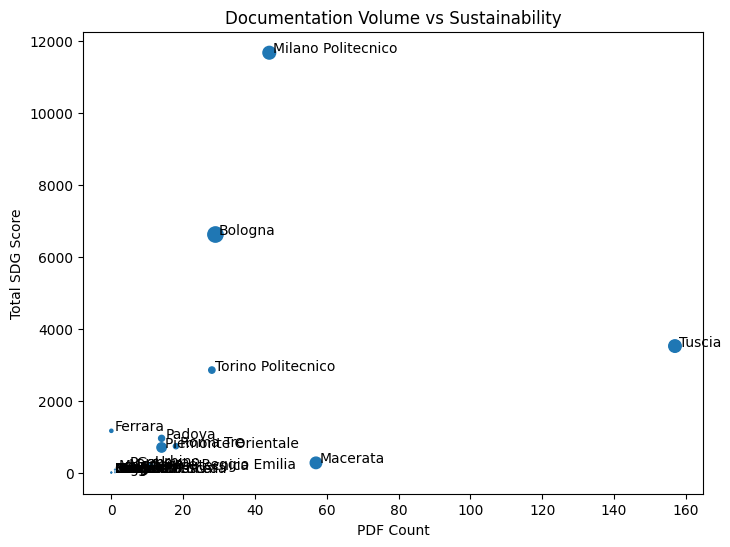

In [ ]:

plt.figure(figsize=(8,6))

plt.scatter(
    df["pdf_count"],
    df["total_sdg_score"],
    s=df["word_count"]/10000,
)

for _, row in df.iterrows():
    plt.text(row["pdf_count"]+1, row["total_sdg_score"], row["university"])

plt.xlabel("PDF Count")
plt.ylabel("Total SDG Score")
plt.title("Documentation Volume vs Sustainability")

plt.show()



## Sustainability Density

This metric estimates how efficiently sustainability content is embedded relative to total text size.


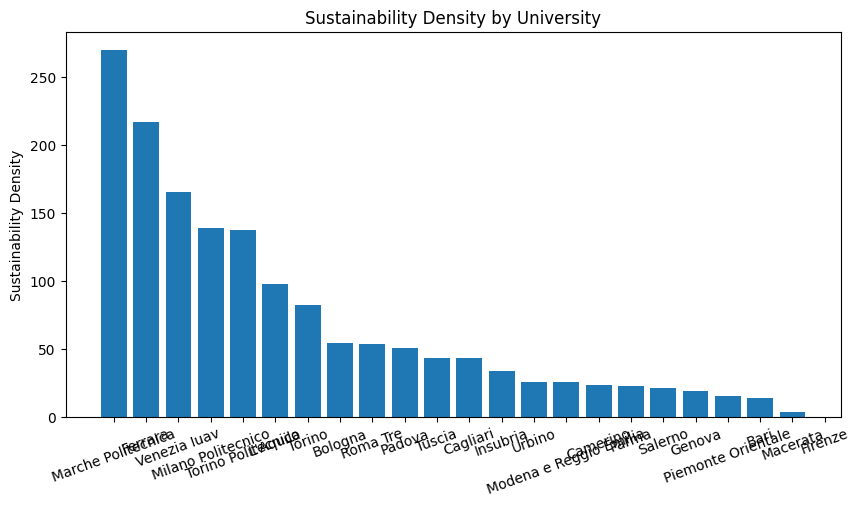

,university,sustainability_density
15,Marche Politecnica,269.930948
12,Ferrara,217.464410
16,Venezia Iuav,165.593376
2,Milano Politecnico,139.165769
4,Torino Politecnico,137.737453
19,L'Aquila,98.107919
17,Torino,82.644628
3,Bologna,54.566704
5,Roma Tre,53.487191
7,Padova,50.793279


In [ ]:

density = df.sort_values("sustainability_density", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(density["university"], density["sustainability_density"])
plt.xticks(rotation=20)
plt.ylabel("Sustainability Density")
plt.title("Sustainability Density by University")
plt.show()

density[[
    "university",
    "sustainability_density"
]]



## Word Frequency Analysis

The dataset includes extracted `top_terms` for each university.  
We generate word clouds to visualise dominant themes.


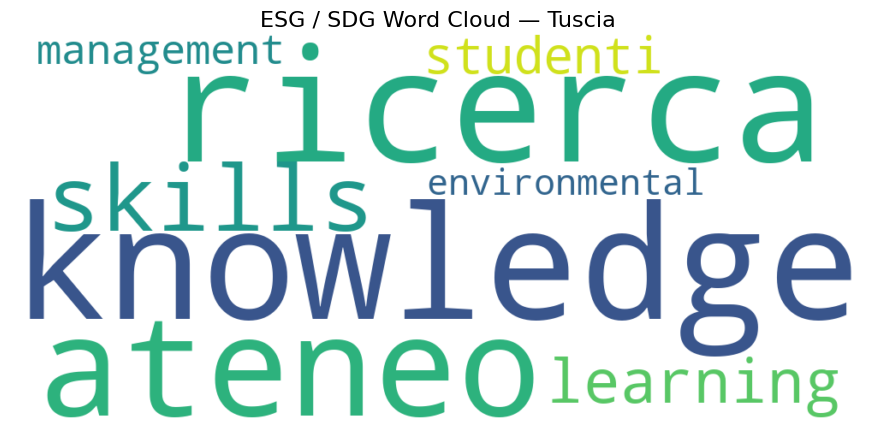

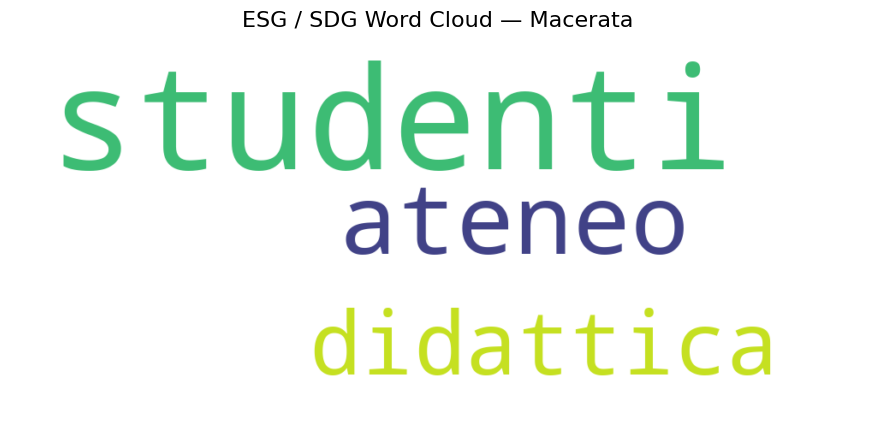

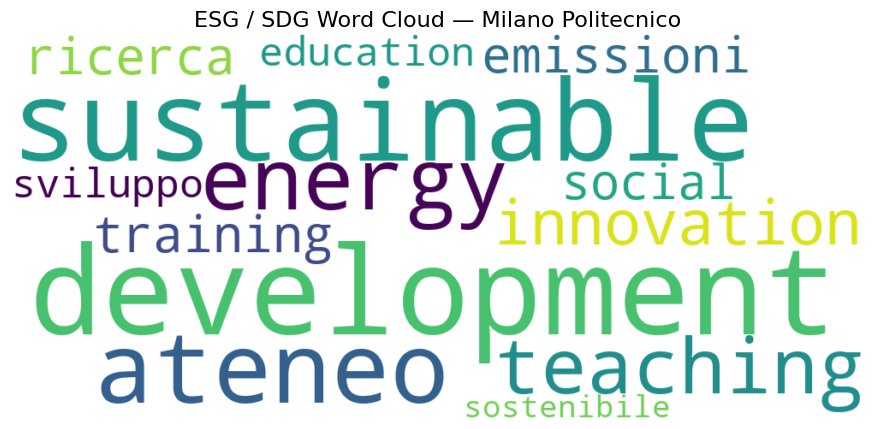

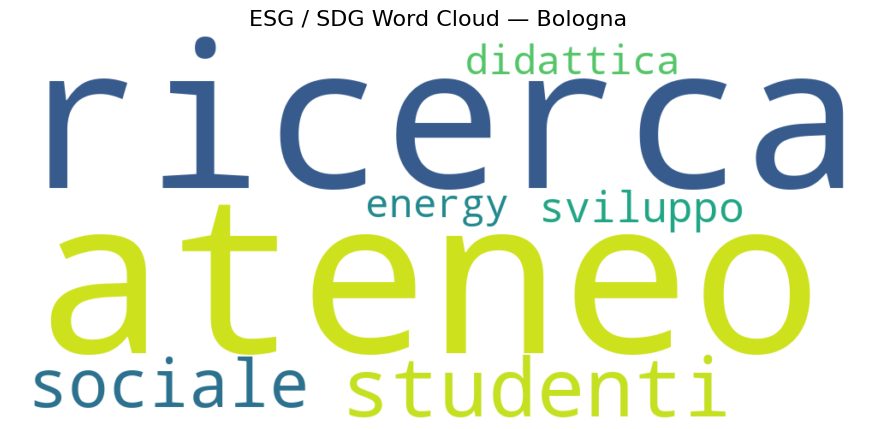

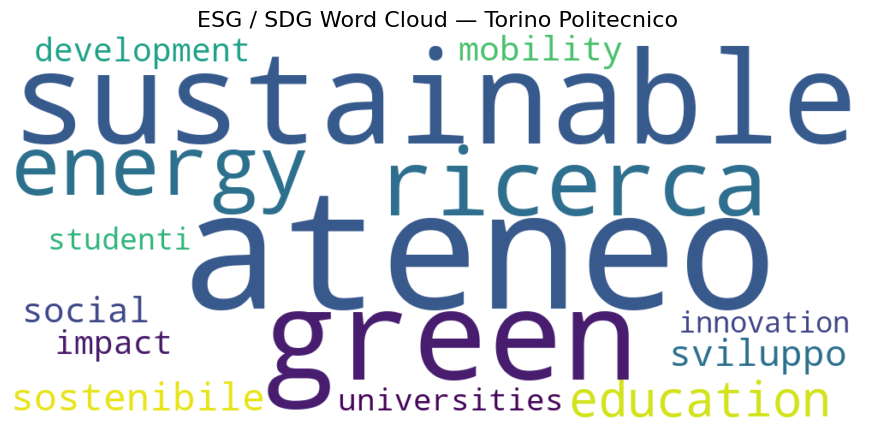

...

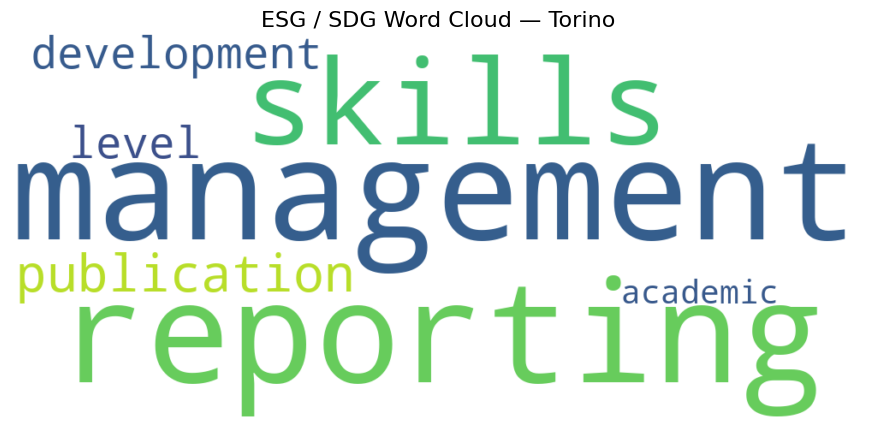

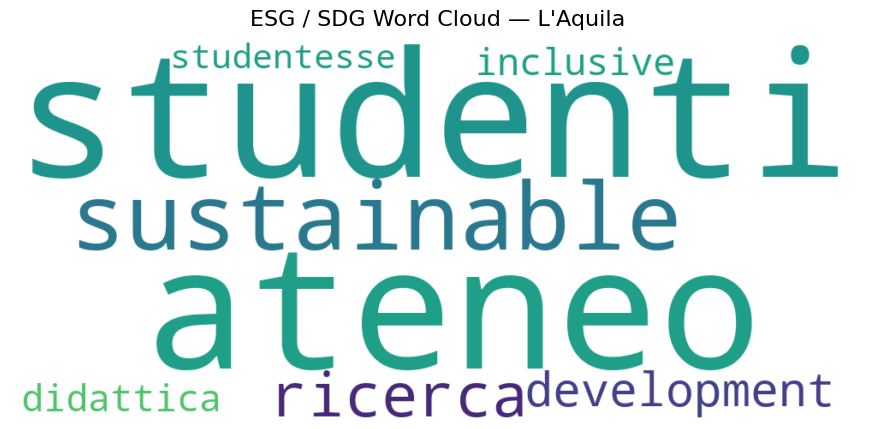

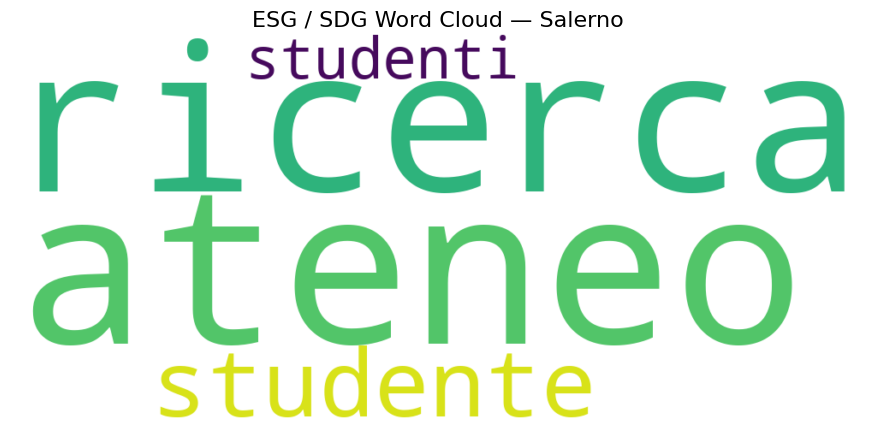

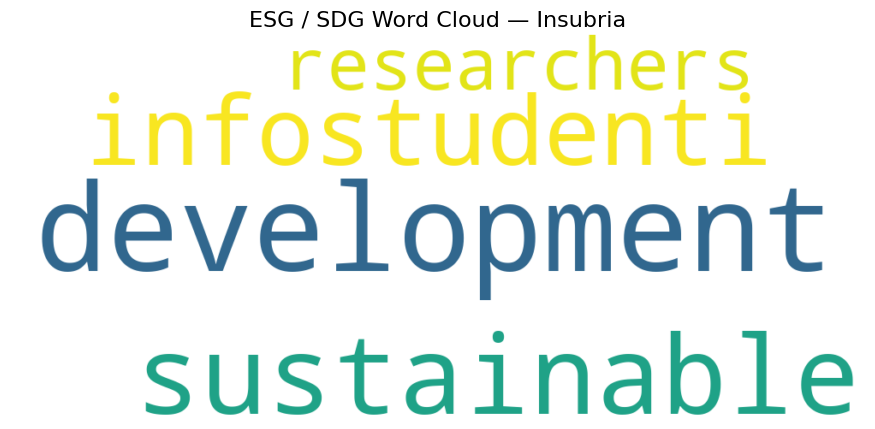

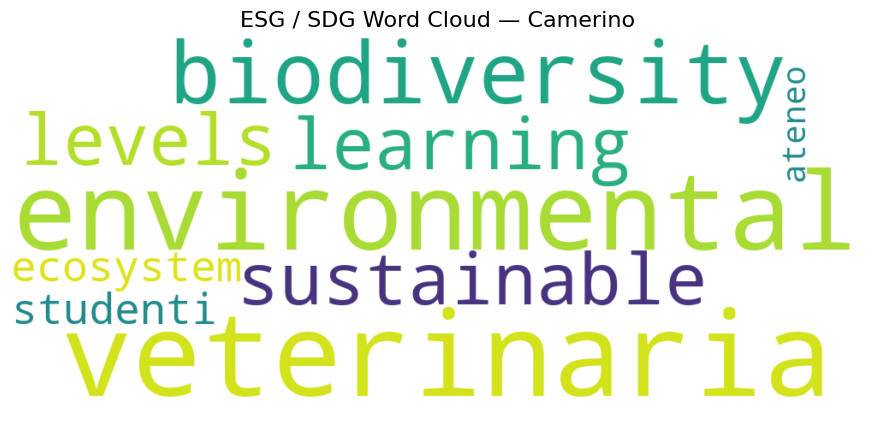

In [ ]:
esg_keywords = {

    # =========================
    # GENERAL ESG / SDG
    # =========================
    "esg","sdg","sdgs","agenda2030","sustainability","sustainable",
    "sostenibilita","sostenibile","sviluppo","development",
    "responsibility","responsabile","impact","impatto",
    "resilience","resilienza","transition","transizione",
    "netzero","carbonneutral","climatepositive",

    # =========================
    # ENVIRONMENT
    # =========================
    "environment","environmental","ambiente","ambientale",
    "ecology","ecological","ecologia","ecosystem","ecosystems",
    "ecosistemi","natural","nature","natura",
    "planet","earth","territory","territorio",
    "land","soil","suolo","water","acqua","air","aria",
    "pollution","pollutione","contamination","contaminazione",
    "marine","oceans","sea","coastal","river","rivers",
    "forest","forests","forestry","forestale","forestali",
    "wildlife","habitat","species","flora","fauna",
    "green","greening","rewilding","conservation","conservazione",
    "restoration","restauro","regeneration","rigenerazione",

    # =========================
    # CLIMATE
    # =========================
    "climate","climatic","climatico","climatica",
    "globalwarming","warming","temperature",
    "adaptation","adaptatione","mitigation","mitigazione",
    "decarbonization","decarbonisation","decarbonizzazione",
    "emissions","emissioni","co2","ghg","methane",
    "carbon","footprint","offset","offsetting",
    "resilience","extremeweather","heatwave","drought",
    "flood","flooding","wildfire","risk","hazard",

    # =========================
    # ENERGY
    # =========================
    "energy","energia","renewable","renewables",
    "solar","photovoltaic","wind","hydrogen",
    "biofuel","biomass","geothermal","storage",
    "battery","smartgrid","efficiency","efficient",
    "electrification","electricity","power",
    "cleanenergy","lowcarbon","energyefficiency",
    "decentralized","microgrid",

    # =========================
    # CIRCULAR ECONOMY
    # =========================
    "circular","circolare","circulareconomy",
    "reuse","recycle","recycling","recycled",
    "recovery","recover","remanufacturing",
    "repair","upcycle","upcycling",
    "waste","wastes","wastewater",
    "compost","composting","resource",
    "resourceefficiency","materials",
    "materialefficiency","zerowaste",

    # =========================
    # BIODIVERSITY
    # =========================
    "biodiversity","biodiversita",
    "species","ecosystem","habitat",
    "pollinator","pollinators","wetlands",
    "protectedareas","ecoregion",
    "agroecology","ecologicalcorridor",
    "naturalcapital","naturebased",
    "conservation","ecorestoration",

    # =========================
    # AGRICULTURE / FOOD
    # =========================
    "agriculture","agricultural","agro",
    "food","foodsystems","nutrition",
    "farming","organic","organicfarming",
    "sustainablefarming","soilhealth",
    "precisionagriculture","livestock",
    "crop","crops","irrigation",
    "agritech","agroforestry",

    # =========================
    # WATER
    # =========================
    "water","freshwater","drinkingwater",
    "sanitation","wastewater","hydrology",
    "watershed","aquifer","desalination",
    "watersecurity","waterquality",
    "hydric","blueeconomy",

    # =========================
    # MOBILITY / CITIES
    # =========================
    "mobility","transport","transportation",
    "urban","city","cities","smartcity",
    "sustainablemobility","cycling",
    "walkability","publictransport",
    "rail","metro","traffic",
    "infrastructure","infrastructures",
    "urbanism","urbanplanning",
    "housing","buildings","construction",
    "bioarchitecture","bioedilizia",

    # =========================
    # SOCIAL
    # =========================
    "social","community","communities",
    "citizens","citizen","public",
    "participation","engagement",
    "wellbeing","wellness","health",
    "mentalhealth","inclusion","inclusive",
    "diversity","equity","equality",
    "justice","humanrights",
    "accessibility","solidarity",
    "cohesion","welfare","poverty",
    "employment","labour","workers",
    "safety","security",

    # =========================
    # GENDER
    # =========================
    "gender","women","female",
    "empowerment","feminism",
    "parity","equalopportunity",
    "inclusivity","discrimination",
    "harassment","bias",

    # =========================
    # EDUCATION
    # =========================
    "education","learning","teaching",
    "training","knowledge","research",
    "innovation","skills","capacity",
    "capacitybuilding","awareness",
    "curriculum","didactics",
    "student","students","academic",
    "pedagogy","school","schools",
    "university","universities",

    # =========================
    # GOVERNANCE
    # =========================
    "governance","ethics","ethical",
    "transparency","accountability",
    "compliance","integrity",
    "anticorruption","corruption",
    "leadership","stakeholder",
    "stakeholders","policy","policies",
    "regulation","standards",
    "reporting","disclosure",
    "audit","riskmanagement",
    "institutional","management",

    # =========================
    # ECONOMY / FINANCE
    # =========================
    "finance","financial","investment",
    "greenfinance","sustainablefinance",
    "economy","economic","growth",
    "inclusivegrowth","circularbusiness",
    "innovation","entrepreneurship",
    "impactinvesting","esginvesting",
    "taxonomy","csrd","euetaxonomy",

    # =========================
    # TECHNOLOGY
    # =========================
    "technology","digital","digitalization",
    "digitalisation","ai","artificialintelligence",
    "machinelearning","iot","bigdata",
    "datadriven","innovation","cleantech",
    "greentech","smart","automation",

    # =========================
    # SDG-SPECIFIC TERMS
    # =========================
    "zerohunger","goodhealth","qualityeducation",
    "cleanwater","cleanenergy",
    "decentwork","industry","innovation",
    "reducedinequalities","responsibleconsumption",
    "climateaction","lifebelowwater",
    "lifeonland","peace","partnerships",

    # =========================
    # ITALIAN UNIVERSITY / POLICY TERMS
    # =========================
    "ricerca","didattica","ateneo",
    "studenti","territoriale",
    "innovazione","energia","emissioni",
    "mobilita","clima","governance",
    "equita","inclusione","benessere",
    "transizione","economiacircolare",
    "rigenerazione","biodiversita",
    "decarbonizzazione","resilienza",
    "partecipazione","comunita",
    "responsabilita","svilupposostenibile",

    # =========================
    # REPORTING / DISCLOSURE
    # =========================
    "gri","sasb","tcfd","issb",
    "csr","csrd","esrs","unep",
    "ungc","scope1","scope2","scope3",
    "materiality","doublemateriality",
    "nonfinancial","sustainabilityreport",
    "integratedreport","impactreport",

    # =========================
    # HEALTH / WELLBEING
    # =========================
    "healthcare","publichealth","medicine",
    "epidemiology","wellbeing","wellness",
    "nutrition","prevention","hospital",
    "care","disability","access",

    # =========================
    # ETHICS / HUMAN RIGHTS
    # =========================
    "humanrights","rights","equity",
    "ethics","ethical","fairness",
    "freedom","dignity","inclusion",
    "justice","transparency","participation",

    # =========================
    # CLIMATE SCIENCE
    # =========================
    "adaptation","mitigation","carbonbudget",
    "decarbonize","climatescience",
    "resilience","vulnerability",
    "sustainablesystems","energytransition",

    # =========================
    # BUILT ENVIRONMENT
    # =========================
    "greenbuilding","leed","breeam",
    "smartbuilding","retrofit",
    "sustainablearchitecture",
    "landscape","urbanecology",
    "naturebasedsolutions",

    # =========================
    # TRANSPORT
    # =========================
    "electricvehicle","ev","charging",
    "micromobility","bike","cycling",
    "publicmobility","sharedmobility",

    # =========================
    # PROCUREMENT / SUPPLY CHAIN
    # =========================
    "supplychain","procurement",
    "sustainableprocurement",
    "traceability","supplier",
    "localproduction","ethicalsourcing",

    # =========================
    # WASTE / MATERIALS
    # =========================
    "plastic","plastics","packaging",
    "singleuse","remanufacture",
    "reuse","landfill","incineration",

    # =========================
    # RESILIENCE / RISK
    # =========================
    "adaptiverisk","resilienceplanning",
    "climaterisk","supplyrisk",
    "preparedness","disasterrisk"
}

def parse_terms(term_string):
    try:
        parsed = ast.literal_eval(term_string)
        return {term.lower(): freq for term, freq in parsed}
    except:
        return {}

for idx, row in df.iterrows():

    terms = parse_terms(row["top_terms"])

    # Filter only ESG/SDG-related terms
    filtered_terms = {
        term: freq
        for term, freq in terms.items()
        if is_relevant(term)
    }

    if len(filtered_terms) == 0:
        continue

    wc = WordCloud(
        width=1000,
        height=450,
        background_color="white"
    ).generate_from_frequencies(filtered_terms)

    plt.figure(figsize=(13,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    plt.title(
        f"ESG / SDG Word Cloud — {row['university']}",
        fontsize=16
    )

    plt.show()

In [ ]:
high_eff_low_sust = ['Bari', 'Bologna', 'Firenze', 'Milano',
                     'Milano Politecnico', 'Padova', 'Parma', 'Torino']

low_eff_high_sust = ['Basilicata', 'Bergamo', 'Chieti e Pescara',
                     'Ferrara', 'Macerata', 'Piemonte Orientale',
                     'Urbino', 'Venezia Iuav']

high_eff_high_sust = ['Cagliari', 'Genova', 'Milano Bicocca',
                      'Modena e Reggio Emilia', 'Roma Tre',
                      'Salerno', 'Torino Politecnico']

low_eff_low_sust = ['Camerino', 'Foggia', 'Insubria',
                    "L'Aquila", 'Marche Politecnica', 'Tuscia']

quadrants = {
    "High Eff / Low Sust": high_eff_low_sust,
    "Low Eff / High Sust": low_eff_high_sust,
    "High Eff / High Sust": high_eff_high_sust,
    "Low Eff / Low Sust": low_eff_low_sust
}

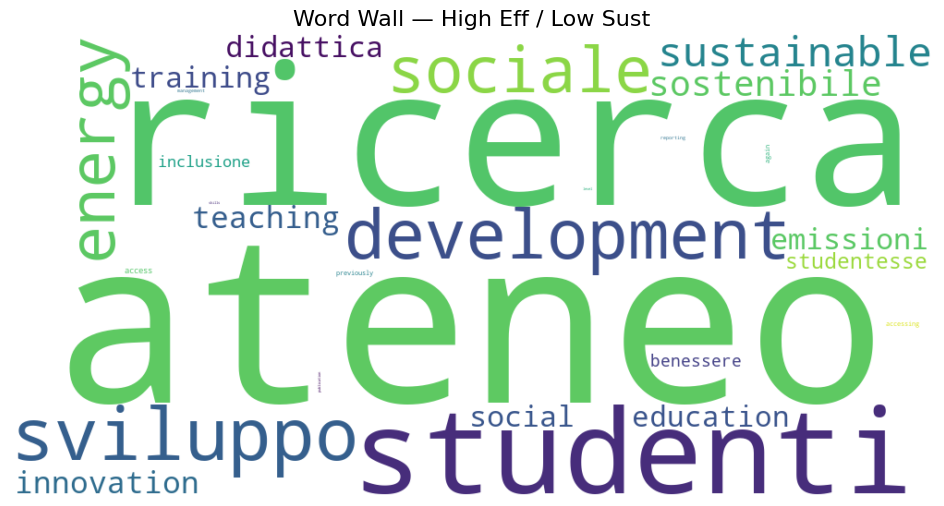

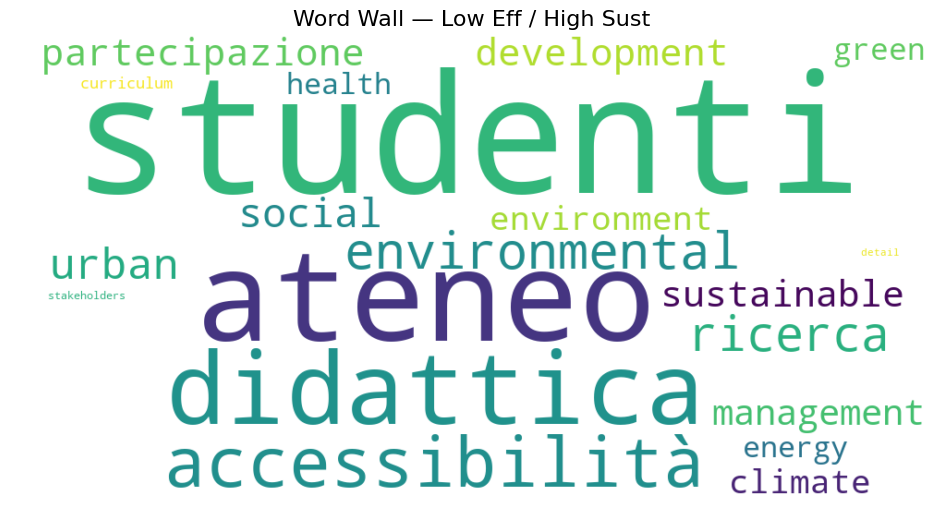

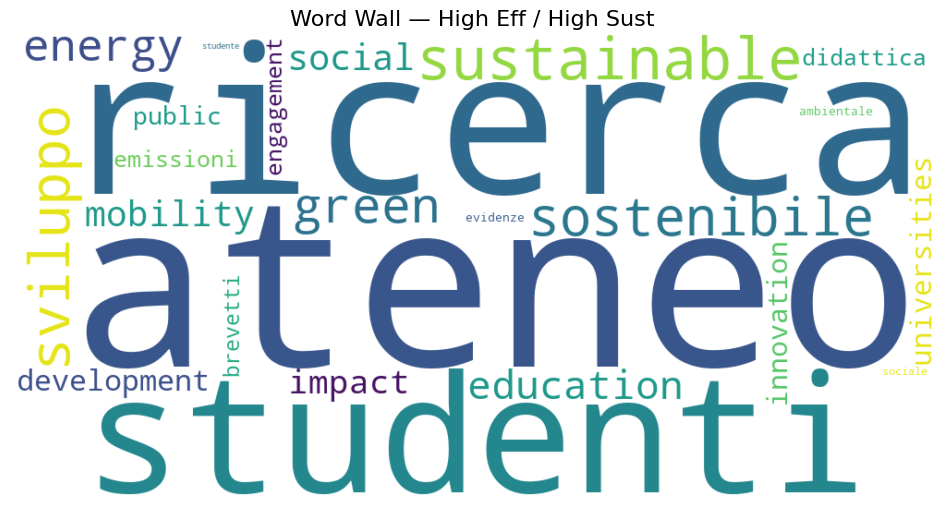

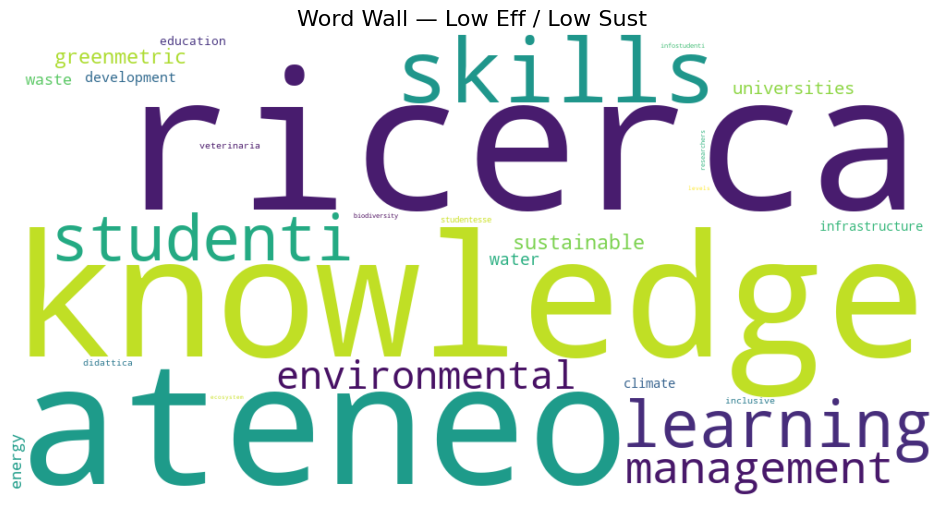

In [ ]:
from collections import Counter
import ast

def parse_terms(term_string):
    try:
        parsed = ast.literal_eval(term_string)
        return {term.lower(): freq for term, freq in parsed}
    except:
        return {}

def build_quadrant_wordcloud(df, university_list, title):

    all_terms = Counter()

    subset = df[df["university"].isin(university_list)]

    for _, row in subset.iterrows():
        terms = parse_terms(row["top_terms"])

        # filter ESG-related terms
        filtered = {
            term: freq
            for term, freq in terms.items()
            if any(keyword in term for keyword in esg_keywords)
        }

        all_terms.update(filtered)

    if len(all_terms) == 0:
        print(f"No terms found for {title}")
        return

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(all_terms)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

for name, uni_list in quadrants.items():
    build_quadrant_wordcloud(df, uni_list, f"Word Wall — {name}")


## SDG Profile Comparison

Radar charts compare universities across SDG dimensions.


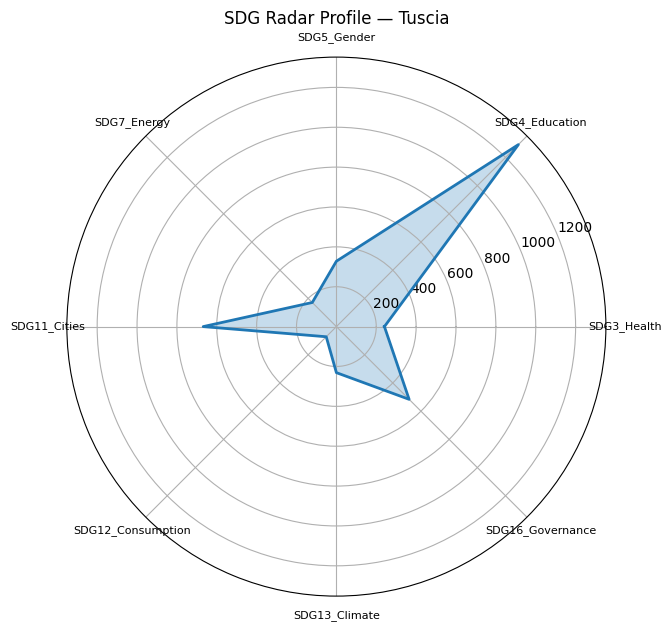

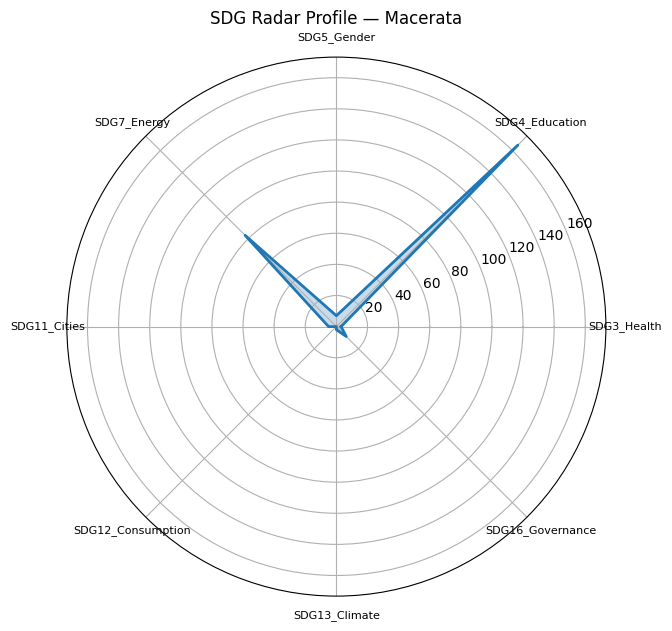

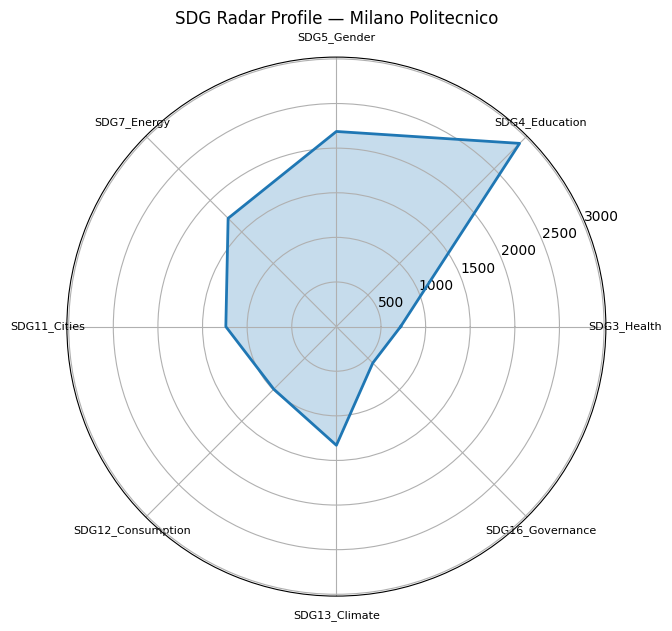

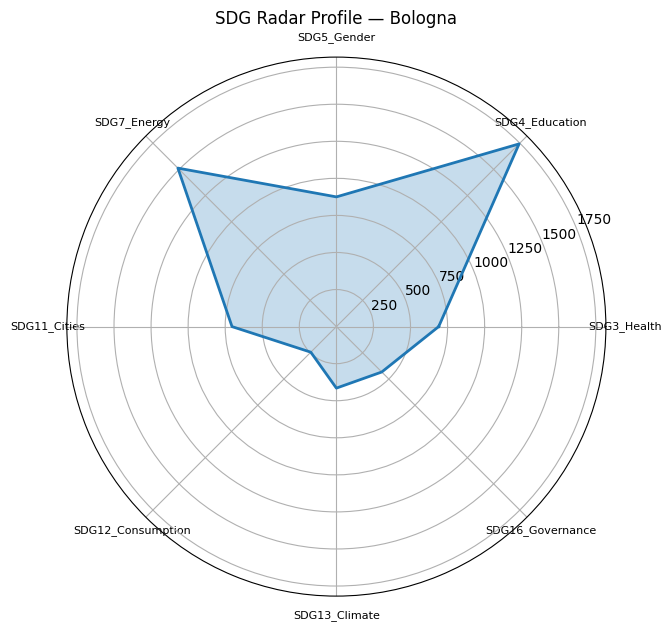

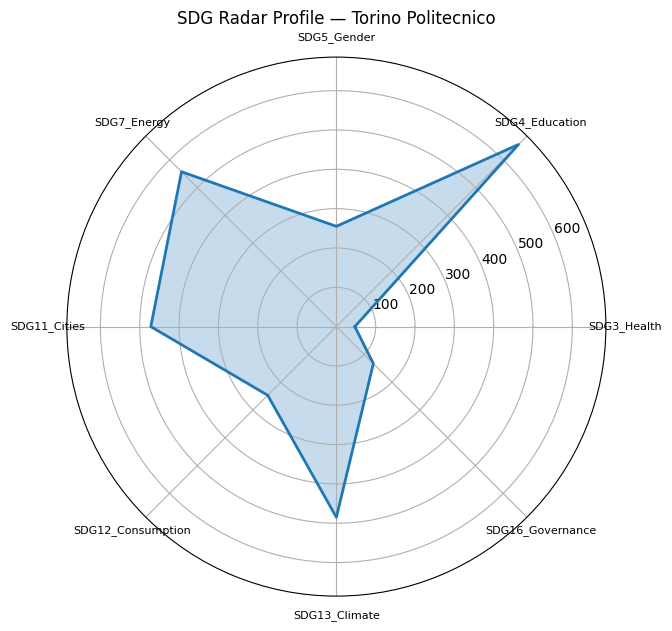

...

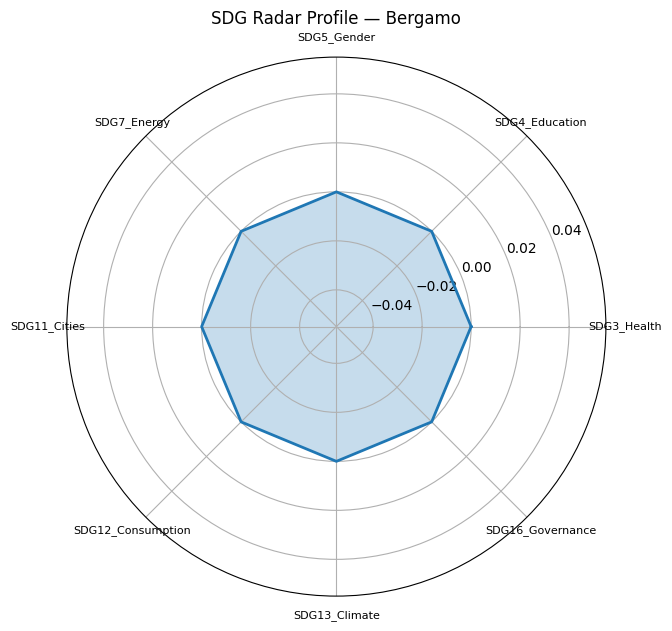

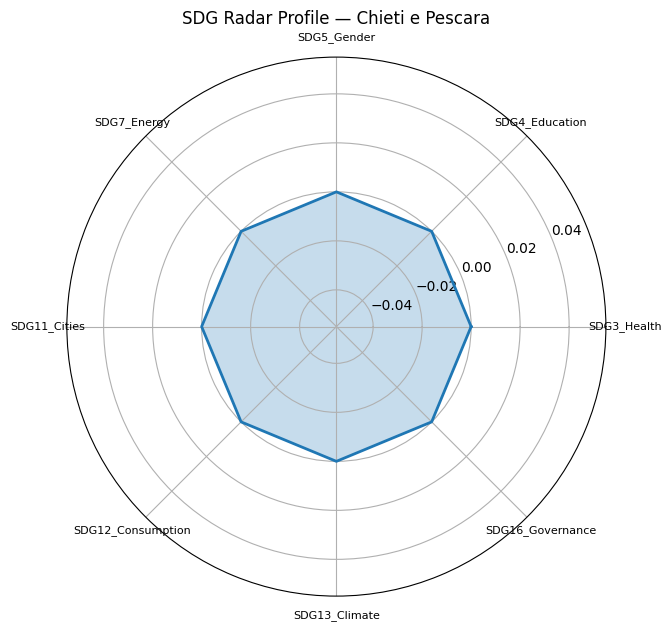

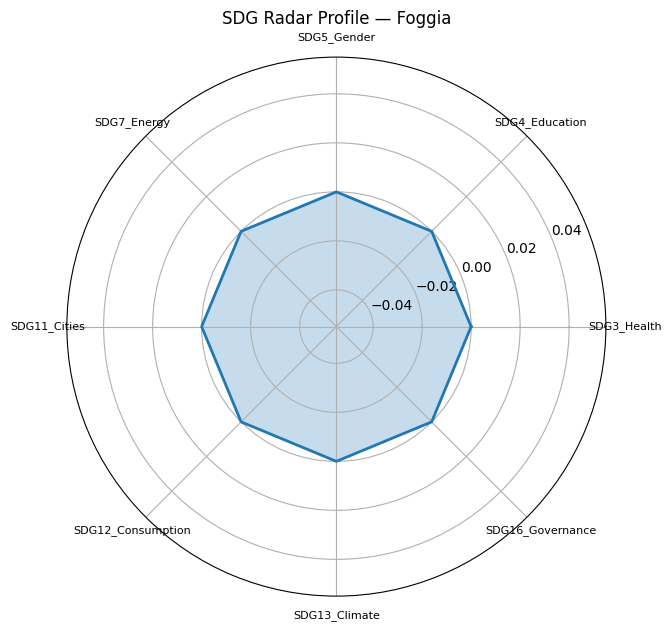

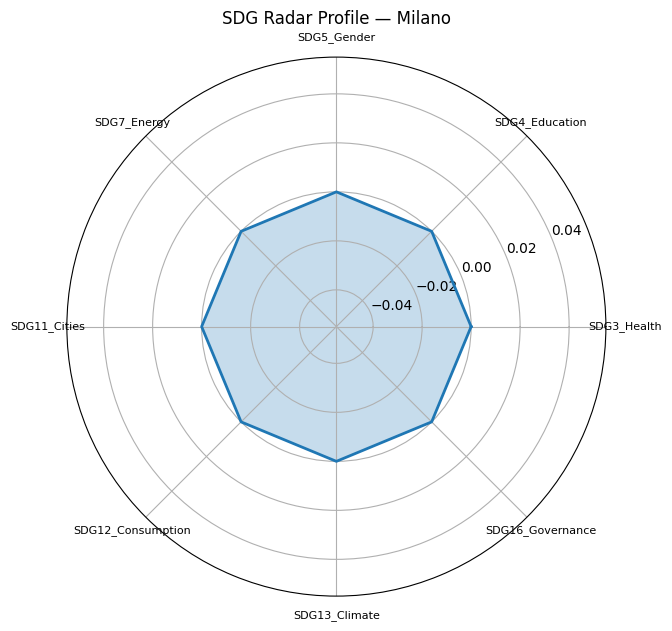

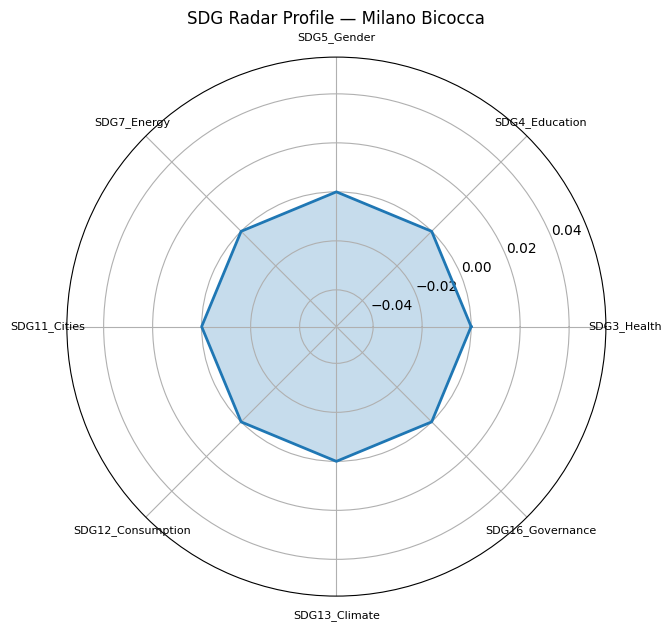

In [ ]:

categories = sdg_cols
N = len(categories)

for _, row in df.iterrows():
    values = row[sdg_cols].tolist()
    values += values[:1]

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig = plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, size=8)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    plt.title(f"SDG Radar Profile — {row['university']}")
    plt.show()



## Clustering Universities

We cluster universities using sustainability and efficiency indicators to identify institutional patterns.


In [ ]:

cluster_features = df[[
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(8,6))

for cluster in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster]

    plt.scatter(
        subset["total_sdg_score"],
        subset["sustainability_density"],
        label=f"Cluster {cluster}"
    )

for _, row in df.iterrows():
    plt.text(
        row["total_sdg_score"],
        row["sustainability_density"],
        row["university"]
    )

plt.xlabel("Total SDG Score")
plt.ylabel("Sustainability Density")
plt.title("University Clusters")
plt.legend()

plt.show()

df[[
    "university",
    "cluster",
    "total_sdg_score",
    "sustainability_density"
]]


ValueError: Input X contains infinity or a value too large for dtype('float64').


# Key Insights

Potential interpretations from this dataset:

1. Universities with higher document production tend to show broader sustainability coverage.
2. Some institutions demonstrate **high sustainability density**, indicating efficient communication of sustainability goals.
3. Technical universities (e.g., Politecnico di Milano) often emphasise:
   - Energy
   - Climate
   - Sustainable development
4. Universities with governance-focused documentation display stronger SDG16 signals.
5. Word-frequency analysis reveals strategic differences:
   - Research-driven institutions emphasise *innovation* and *development*
   - Teaching-focused institutions emphasise *students*, *courses*, and *didactics*

This notebook can be extended with:
- External rankings
- QS/THE integration
- Financial efficiency metrics
- Time-series sustainability tracking
- NLP topic modelling



## SDG Profile Comparison

Radar charts compare universities across SDG dimensions.


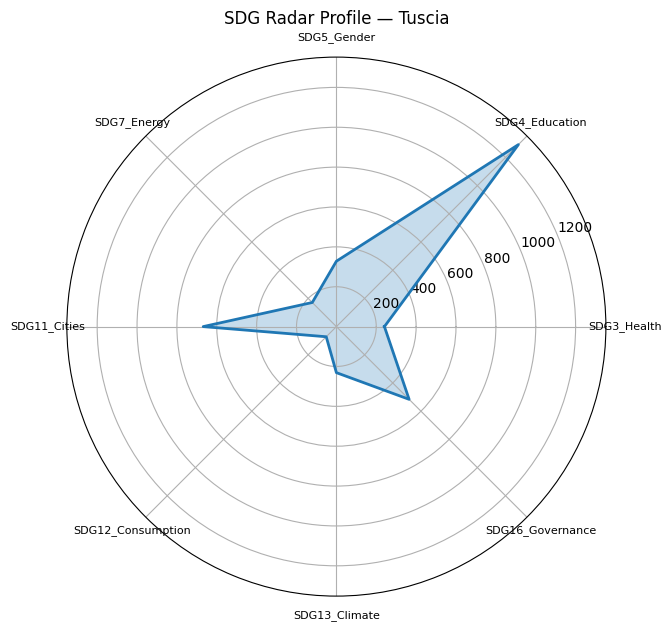

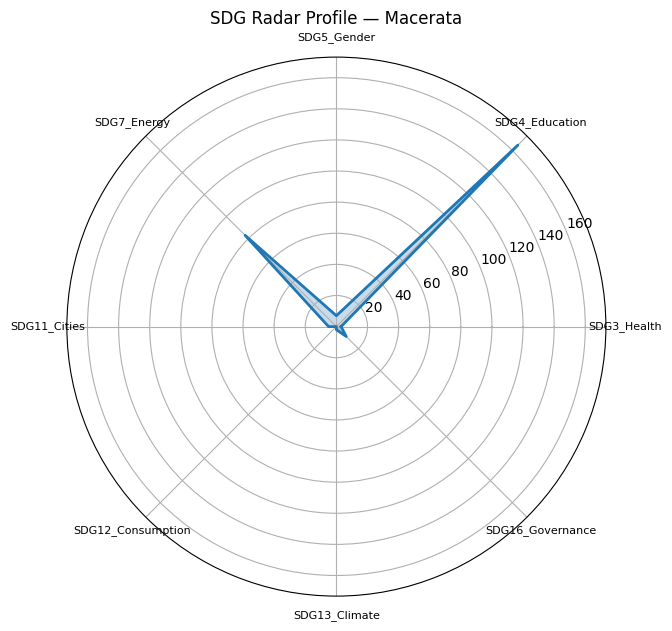

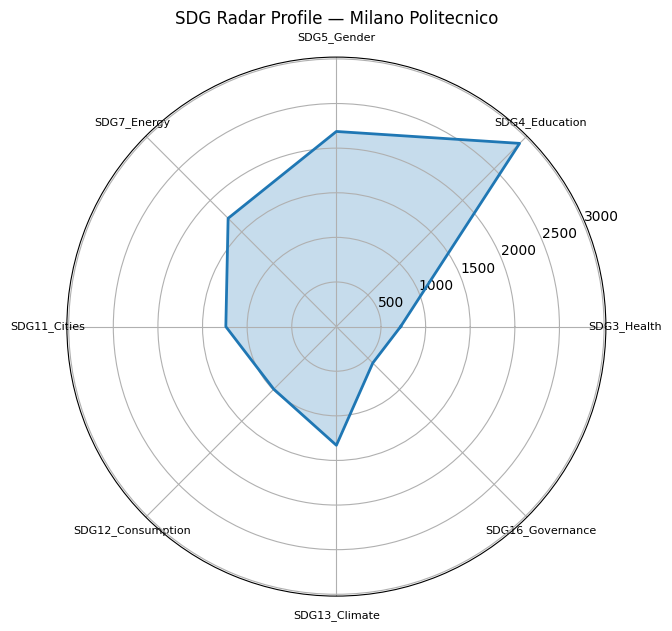

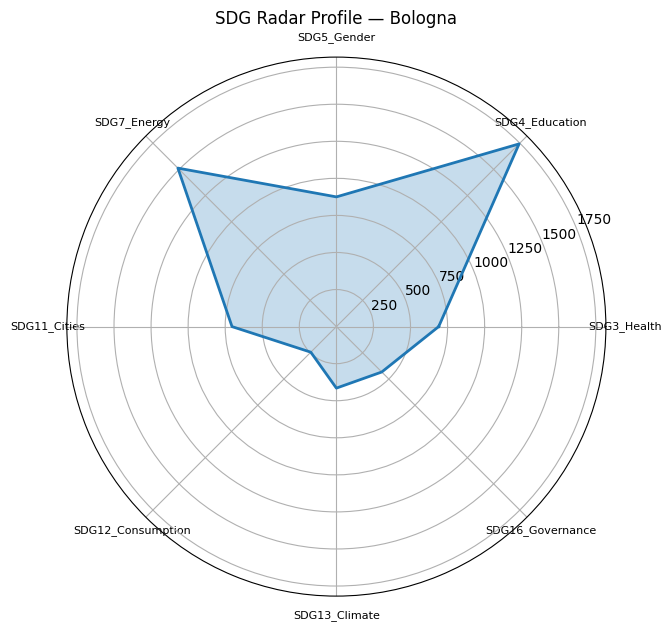

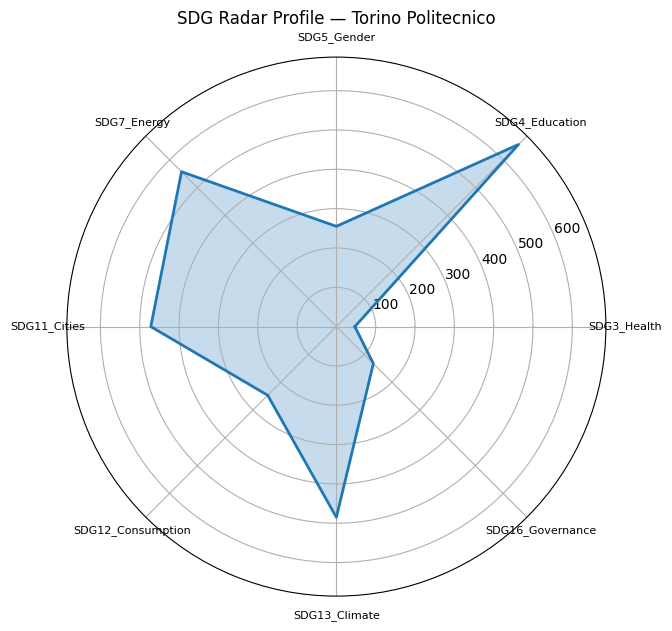

...

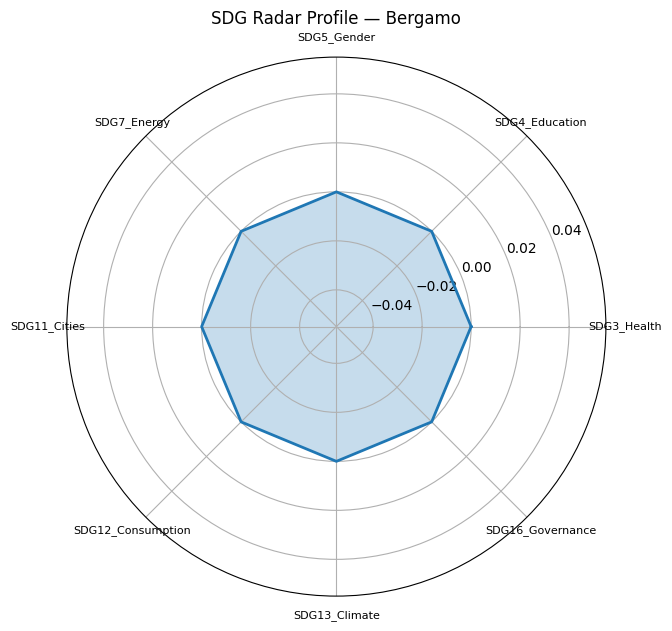

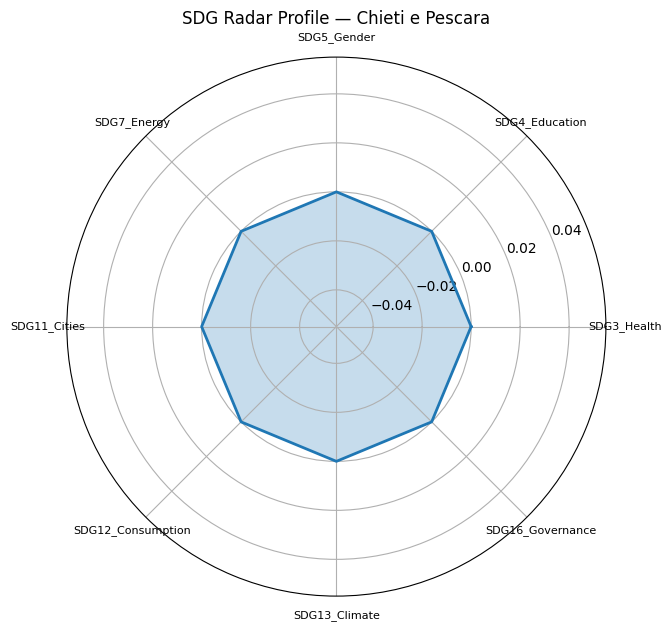

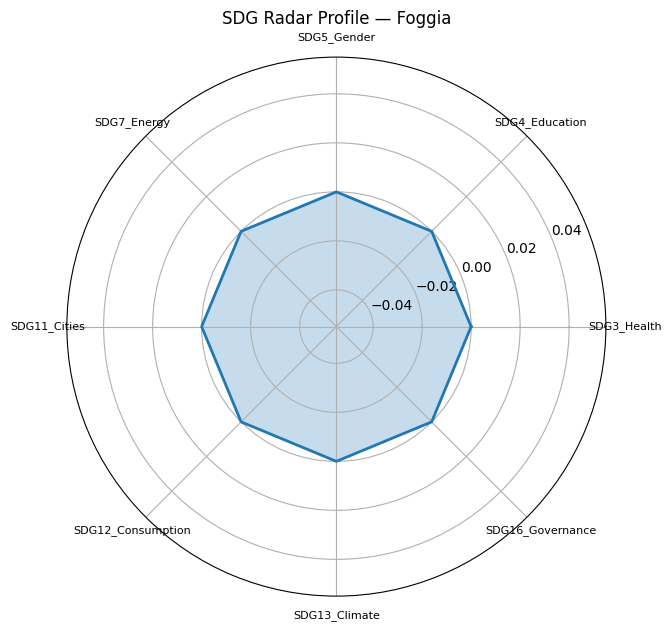

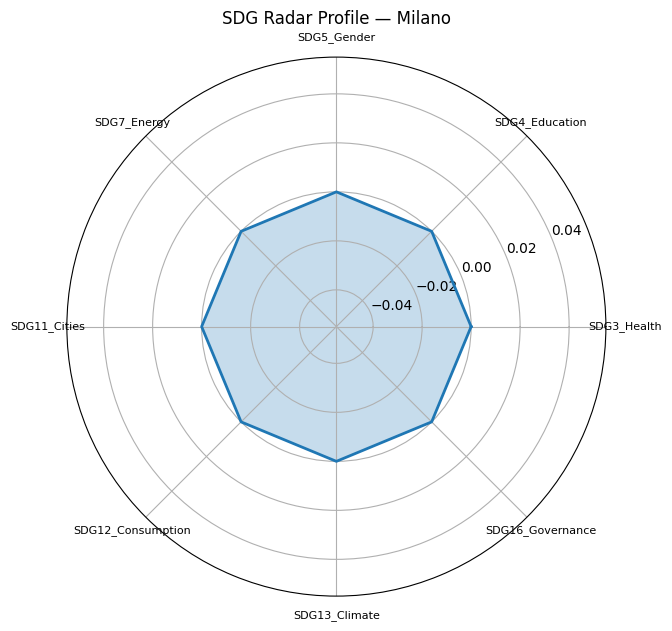

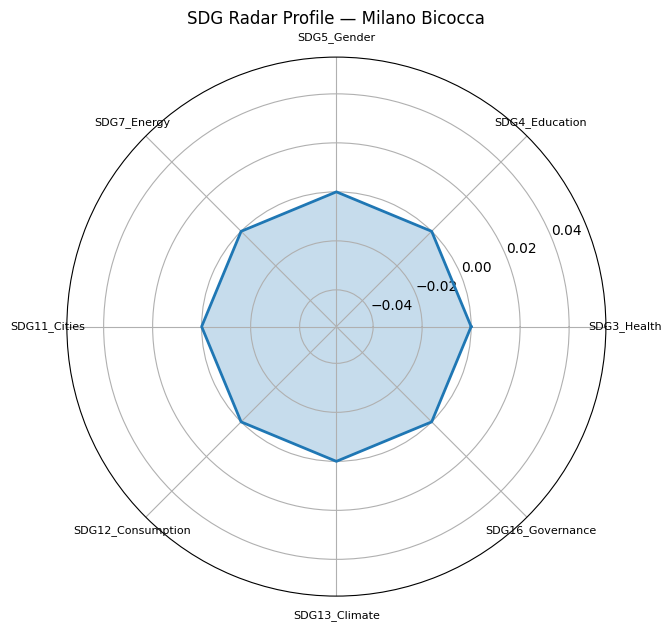

In [ ]:

categories = sdg_cols
N = len(categories)

for _, row in df.iterrows():
    values = row[sdg_cols].tolist()
    values += values[:1]

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig = plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, size=8)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    plt.title(f"SDG Radar Profile — {row['university']}")
    plt.show()



## Clustering Universities

We cluster universities using sustainability and efficiency indicators to identify institutional patterns.


In [ ]:

cluster_features = df[[
    "total_sdg_score",
    "sustainability_density",
    "docs_per_page",
    "words_per_pdf"
]]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(8,6))

for cluster in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster]

    plt.scatter(
        subset["total_sdg_score"],
        subset["sustainability_density"],
        label=f"Cluster {cluster}"
    )

for _, row in df.iterrows():
    plt.text(
        row["total_sdg_score"],
        row["sustainability_density"],
        row["university"]
    )

plt.xlabel("Total SDG Score")
plt.ylabel("Sustainability Density")
plt.title("University Clusters")
plt.legend()

plt.show()

df[[
    "university",
    "cluster",
    "total_sdg_score",
    "sustainability_density"
]]


ValueError: Input X contains infinity or a value too large for dtype('float64').


# Key Insights

Potential interpretations from this dataset:

1. Universities with higher document production tend to show broader sustainability coverage.
2. Some institutions demonstrate **high sustainability density**, indicating efficient communication of sustainability goals.
3. Technical universities (e.g., Politecnico di Milano) often emphasise:
   - Energy
   - Climate
   - Sustainable development
4. Universities with governance-focused documentation display stronger SDG16 signals.
5. Word-frequency analysis reveals strategic differences:
   - Research-driven institutions emphasise *innovation* and *development*
   - Teaching-focused institutions emphasise *students*, *courses*, and *didactics*

This notebook can be extended with:
- External rankings
- QS/THE integration
- Financial efficiency metrics
- Time-series sustainability tracking
- NLP topic modelling
